In [262]:
from datasets import load_dataset
import pandas as pd
from sklearn.model_selection import train_test_split

vessels = [
    "cps_poseidon",
    "oss_ceto",
    "cps_triton"
]

dfs = []

for vessel in vessels:
    ds = load_dataset(
        "krohnedigital/FuelCast",
        vessel,
        split="train"
    )

    temp = ds.to_pandas()
    temp["vessel_name"] = vessel

    dfs.append(temp)

df = pd.concat(dfs, ignore_index=True)

print(df.shape)
print(df["vessel_name"].value_counts())

(173986, 93)
vessel_name
cps_poseidon    105422
oss_ceto         43213
cps_triton       25351
Name: count, dtype: int64


In [263]:
df.head()

,Consumer_Boiler1_FuelType,Consumer_Boiler1_MomentaryFuel,Consumer_Boiler2_FuelType,Consumer_Boiler2_MomentaryFuel,Consumer_GeneratorEngine1_FuelType,Consumer_GeneratorEngine1_MomentaryFuel,Consumer_GeneratorEngine1_RotationSpeed,Consumer_GeneratorEngine1_ShaftPower,Consumer_GeneratorEngine2_FuelType,Consumer_GeneratorEngine2_MomentaryFuel,...,Consumer_MainEnginePort_MomentaryFuel,Consumer_MainEnginePort_RotationSpeed,Consumer_MainEnginePort_ShaftPower,Consumer_MainEngineStarboard_FuelType,Consumer_MainEngineStarboard_MomentaryFuel,Consumer_MainEngineStarboard_RotationSpeed,Consumer_MainEngineStarboard_ShaftPower,Ship_AirTemperature,Ship_AnemometerWindDirection,Ship_AnemometerWindSpeed
0,DM,0.0,DM,0.0,RM 380,0.0,1.0,1.836682e-38,RM 380,0.291173,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,DM,0.0,DM,0.0,RM 380,0.0,0.8,1.836682e-38,RM 380,0.288768,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,DM,0.0,DM,0.0,RM 380,0.0,1.0,0.000000e+00,RM 380,0.295024,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,DM,0.0,DM,0.0,RM 380,0.0,1.0,0.000000e+00,RM 380,0.291656,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,DM,0.0,DM,0.0,RM 380,0.0,0.6,3.673364e-38,RM 380,0.289747,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [264]:
df.tail()

,Consumer_Boiler1_FuelType,Consumer_Boiler1_MomentaryFuel,Consumer_Boiler2_FuelType,Consumer_Boiler2_MomentaryFuel,Consumer_GeneratorEngine1_FuelType,Consumer_GeneratorEngine1_MomentaryFuel,Consumer_GeneratorEngine1_RotationSpeed,Consumer_GeneratorEngine1_ShaftPower,Consumer_GeneratorEngine2_FuelType,Consumer_GeneratorEngine2_MomentaryFuel,...,Consumer_MainEnginePort_MomentaryFuel,Consumer_MainEnginePort_RotationSpeed,Consumer_MainEnginePort_ShaftPower,Consumer_MainEngineStarboard_FuelType,Consumer_MainEngineStarboard_MomentaryFuel,Consumer_MainEngineStarboard_RotationSpeed,Consumer_MainEngineStarboard_ShaftPower,Ship_AirTemperature,Ship_AnemometerWindDirection,Ship_AnemometerWindSpeed
173981,NaN,NaN,NaN,NaN,HVO 30,0.0,NaN,0.0,HVO 30,0.0,...,0.110229,488.64,1444680.0,HVO 30,0.081532,488.64,1398600.0,6.52,351.5,12.90
173982,NaN,NaN,NaN,NaN,HVO 30,0.0,NaN,0.0,HVO 30,0.0,...,0.109087,488.68,1444340.0,HVO 30,0.084144,488.68,1497760.0,6.08,330.5,12.78
173983,NaN,NaN,NaN,NaN,HVO 30,0.0,NaN,0.0,HVO 30,0.0,...,0.109629,488.68,1436760.0,HVO 30,0.081628,488.68,1427760.0,6.34,324.5,9.94
173984,NaN,NaN,NaN,NaN,HVO 30,0.0,NaN,0.0,HVO 30,0.0,...,0.110659,488.74,1466640.0,HVO 30,0.081464,488.74,1419200.0,6.38,325.0,11.88
173985,NaN,NaN,NaN,NaN,HVO 30,NaN,NaN,NaN,HVO 30,NaN,...,NaN,NaN,NaN,HVO 30,NaN,NaN,NaN,NaN,NaN,NaN


In [265]:
df.isna().sum()

Consumer_Boiler1_FuelType                      68564
Consumer_Boiler1_MomentaryFuel                 68591
Consumer_Boiler2_FuelType                      68564
Consumer_Boiler2_MomentaryFuel                 68591
Consumer_GeneratorEngine1_FuelType             43213
                                               ...  
Consumer_MainEngineStarboard_RotationSpeed    148645
Consumer_MainEngineStarboard_ShaftPower       148645
Ship_AirTemperature                           148645
Ship_AnemometerWindDirection                  148645
Ship_AnemometerWindSpeed                      148645
Length: 93, dtype: int64

In [266]:
df['vessel_name'].value_counts()

vessel_name
cps_poseidon    105422
oss_ceto         43213
cps_triton       25351
Name: count, dtype: int64

In [267]:
print(df.columns.tolist())

['Consumer_Boiler1_FuelType', 'Consumer_Boiler1_MomentaryFuel', 'Consumer_Boiler2_FuelType', 'Consumer_Boiler2_MomentaryFuel', 'Consumer_GeneratorEngine1_FuelType', 'Consumer_GeneratorEngine1_MomentaryFuel', 'Consumer_GeneratorEngine1_RotationSpeed', 'Consumer_GeneratorEngine1_ShaftPower', 'Consumer_GeneratorEngine2_FuelType', 'Consumer_GeneratorEngine2_MomentaryFuel', 'Consumer_GeneratorEngine2_RotationSpeed', 'Consumer_GeneratorEngine2_ShaftPower', 'Consumer_GeneratorEngine3_FuelType', 'Consumer_GeneratorEngine3_MomentaryFuel', 'Consumer_GeneratorEngine3_RotationSpeed', 'Consumer_GeneratorEngine3_ShaftPower', 'Consumer_GeneratorEngine4_FuelType', 'Consumer_GeneratorEngine4_MomentaryFuel', 'Consumer_GeneratorEngine4_RotationSpeed', 'Consumer_GeneratorEngine4_ShaftPower', 'Consumer_GeneratorEngine5_FuelType', 'Consumer_GeneratorEngine5_MomentaryFuel', 'Consumer_GeneratorEngine5_RotationSpeed', 'Consumer_GeneratorEngine5_ShaftPower', 'Consumer_Total_MomentaryFuel', 'Consumer_Total_Shaft

In [268]:
[c for c in df.columns if "Fuel" in c or "fuel" in c]

['Consumer_Boiler1_FuelType',
 'Consumer_Boiler1_MomentaryFuel',
 'Consumer_Boiler2_FuelType',
 'Consumer_Boiler2_MomentaryFuel',
 'Consumer_GeneratorEngine1_FuelType',
 'Consumer_GeneratorEngine1_MomentaryFuel',
 'Consumer_GeneratorEngine2_FuelType',
 'Consumer_GeneratorEngine2_MomentaryFuel',
 'Consumer_GeneratorEngine3_FuelType',
 'Consumer_GeneratorEngine3_MomentaryFuel',
 'Consumer_GeneratorEngine4_FuelType',
 'Consumer_GeneratorEngine4_MomentaryFuel',
 'Consumer_GeneratorEngine5_FuelType',
 'Consumer_GeneratorEngine5_MomentaryFuel',
 'Consumer_Total_MomentaryFuel',
 'Consumer_DeckSupply_FuelType',
 'Consumer_DeckSupply_MomentaryFuel',
 'Consumer_EngineRoom1_FuelType',
 'Consumer_EngineRoom1_MomentaryFuel',
 'Consumer_EngineRoom2_FuelType',
 'Consumer_EngineRoom2_MomentaryFuel',
 'Consumer_Incinerator_FuelType',
 'Consumer_Incinerator_MomentaryFuel',
 'Consumer_Boiler_FuelType',
 'Consumer_Boiler_MomentaryFuel',
 'Consumer_MainEnginePort_FuelType',
 'Consumer_MainEnginePort_Moment

In [269]:
df["ME_Total_MomentaryFuel"] = (
    df["Consumer_MainEnginePort_MomentaryFuel"]
    + df["Consumer_MainEngineStarboard_MomentaryFuel"]
)

In [270]:
df.head()

,Consumer_Boiler1_FuelType,Consumer_Boiler1_MomentaryFuel,Consumer_Boiler2_FuelType,Consumer_Boiler2_MomentaryFuel,Consumer_GeneratorEngine1_FuelType,Consumer_GeneratorEngine1_MomentaryFuel,Consumer_GeneratorEngine1_RotationSpeed,Consumer_GeneratorEngine1_ShaftPower,Consumer_GeneratorEngine2_FuelType,Consumer_GeneratorEngine2_MomentaryFuel,...,Consumer_MainEnginePort_RotationSpeed,Consumer_MainEnginePort_ShaftPower,Consumer_MainEngineStarboard_FuelType,Consumer_MainEngineStarboard_MomentaryFuel,Consumer_MainEngineStarboard_RotationSpeed,Consumer_MainEngineStarboard_ShaftPower,Ship_AirTemperature,Ship_AnemometerWindDirection,Ship_AnemometerWindSpeed,ME_Total_MomentaryFuel
0,DM,0.0,DM,0.0,RM 380,0.0,1.0,1.836682e-38,RM 380,0.291173,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,DM,0.0,DM,0.0,RM 380,0.0,0.8,1.836682e-38,RM 380,0.288768,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,DM,0.0,DM,0.0,RM 380,0.0,1.0,0.000000e+00,RM 380,0.295024,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,DM,0.0,DM,0.0,RM 380,0.0,1.0,0.000000e+00,RM 380,0.291656,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,DM,0.0,DM,0.0,RM 380,0.0,0.6,3.673364e-38,RM 380,0.289747,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [271]:
print(df["ME_Total_MomentaryFuel"].describe())

count    25341.000000
mean         0.165384
std          0.082403
min          0.000000
25%          0.131293
50%          0.199499
75%          0.217898
max          0.351613
Name: ME_Total_MomentaryFuel, dtype: float64


In [272]:
print(df["ME_Total_MomentaryFuel"].isna().sum())
print(df["ME_Total_MomentaryFuel"].min())
print(df["ME_Total_MomentaryFuel"].max())

148645
0.0
0.35161329820421006


In [273]:
print("Total rows:", len(df))

print("Zero fuel rows:",
      (df["ME_Total_MomentaryFuel"] == 0).sum())

print("Non-zero fuel rows:",
      (df["ME_Total_MomentaryFuel"] > 0).sum())

Total rows: 173986
Zero fuel rows: 2276
Non-zero fuel rows: 23065


In [274]:
print(
    df.groupby("vessel_name")["ME_Total_MomentaryFuel"]
      .agg(["count", "min", "max", "mean"])
)

              count  min       max      mean
vessel_name                                 
cps_poseidon      0  NaN       NaN       NaN
cps_triton    25341  0.0  0.351613  0.165384
oss_ceto          0  NaN       NaN       NaN


In [275]:
# Check missing values and data types
info = pd.DataFrame({
    "dtype": df.dtypes,
    "missing": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(2)
})

info.sort_values("missing_pct").head(50)

,dtype,missing,missing_pct
Consumer_Total_MomentaryFuel,float64,0,0.00
Consumer_Total_ShaftPower,float64,0,0.00
vessel_name,str,0,0.00
index,float64,12,0.01
Weather_WaveHeight,float64,283,0.16
Weather_WaveDirection,float64,283,0.16
Weather_SwellWavePeriod,float64,283,0.16
Weather_Temperature2M,float64,283,0.16
Weather_WeatherCode,float64,283,0.16
Weather_WavePeriod,float64,283,0.16


In [276]:
keywords = [
    "Speed",
    "Power",
    "Torque",
    "Rotation",
    "Draft",
    "Trim",
    "Wind",
    "Wave",
    "Current",
    "Fuel"
]

relevant_cols = [
    col for col in df.columns
    if any(k.lower() in col.lower() for k in keywords)
]

print("\n".join(relevant_cols))

Consumer_Boiler1_FuelType
Consumer_Boiler1_MomentaryFuel
Consumer_Boiler2_FuelType
Consumer_Boiler2_MomentaryFuel
Consumer_GeneratorEngine1_FuelType
Consumer_GeneratorEngine1_MomentaryFuel
Consumer_GeneratorEngine1_RotationSpeed
Consumer_GeneratorEngine1_ShaftPower
Consumer_GeneratorEngine2_FuelType
Consumer_GeneratorEngine2_MomentaryFuel
Consumer_GeneratorEngine2_RotationSpeed
Consumer_GeneratorEngine2_ShaftPower
Consumer_GeneratorEngine3_FuelType
Consumer_GeneratorEngine3_MomentaryFuel
Consumer_GeneratorEngine3_RotationSpeed
Consumer_GeneratorEngine3_ShaftPower
Consumer_GeneratorEngine4_FuelType
Consumer_GeneratorEngine4_MomentaryFuel
Consumer_GeneratorEngine4_RotationSpeed
Consumer_GeneratorEngine4_ShaftPower
Consumer_GeneratorEngine5_FuelType
Consumer_GeneratorEngine5_MomentaryFuel
Consumer_GeneratorEngine5_RotationSpeed
Consumer_GeneratorEngine5_ShaftPower
Consumer_Total_MomentaryFuel
Consumer_Total_ShaftPower
Propeller_Port_RotationSpeed
Propeller_Port_ShaftPower
Propeller_Port_S

In [277]:
triton = df[
    (df["vessel_name"] == "cps_triton") &
    (df["ME_Total_MomentaryFuel"] > 0)
].copy()

print("Triton valid rows:", len(triton))

Triton valid rows: 23065


In [278]:

triton.describe().T

,count,mean,std,min,25%,50%,75%,max
Consumer_Boiler1_MomentaryFuel,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Consumer_Boiler2_MomentaryFuel,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Consumer_GeneratorEngine1_MomentaryFuel,23065.0,1.705653e-03,0.007470,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,4.869858e-02
Consumer_GeneratorEngine1_RotationSpeed,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Consumer_GeneratorEngine1_ShaftPower,23065.0,2.802328e+04,125783.293703,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,8.296000e+05
...,...,...,...,...,...,...,...,...
Consumer_MainEngineStarboard_ShaftPower,23065.0,1.186423e+06,548628.676791,0.000000,1.004900e+06,1.374260e+06,1.519980e+06,2.846960e+06
Ship_AirTemperature,23065.0,6.883701e+00,4.147985,-10.880000,4.120000e+00,7.220000e+00,9.700000e+00,2.032000e+01
Ship_AnemometerWindDirection,23065.0,1.735341e+02,118.063921,3.000000,5.900000e+01,1.610000e+02,2.870000e+02,3.600000e+02
Ship_AnemometerWindSpeed,23065.0,9.568902e+00,5.745069,0.000000,5.140000e+00,8.560000e+00,1.306000e+01,3.722000e+01


In [279]:
corr = triton.corr(numeric_only=True)["ME_Total_MomentaryFuel"] \
              .sort_values(ascending=False)

print(corr.head(20))

ME_Total_MomentaryFuel                        1.000000
Consumer_MainEnginePort_MomentaryFuel         0.990798
Consumer_MainEngineStarboard_MomentaryFuel    0.988869
Consumer_Total_MomentaryFuel                  0.978774
Propeller_Total_ShaftPower                    0.962884
Consumer_MainEnginePort_ShaftPower            0.960486
Propeller_Port_ShaftPower                     0.960486
Propeller_Starboard_ShaftTorque               0.960005
Propeller_Starboard_ShaftPower                0.958934
Consumer_MainEngineStarboard_ShaftPower       0.958934
Propeller_Port_ShaftTorque                    0.955913
Consumer_Total_ShaftPower                     0.919114
Ship_SpeedOverGround                          0.844229
Propeller_Port_RotationSpeed                  0.825133
Propeller_Starboard_RotationSpeed             0.820708
Consumer_MainEnginePort_RotationSpeed         0.806394
Consumer_MainEngineStarboard_RotationSpeed    0.806394
Ship_AnemometerWindSpeed                      0.457912
Weather_Wa

In [280]:
features_to_check = [
    "Ship_SpeedOverGround",
    "Propeller_Total_ShaftPower",
    "Propeller_Port_ShaftTorque",
    "Propeller_Starboard_ShaftTorque",
    "Ship_AnemometerWindSpeed",
    "Weather_WaveHeight"
]

print(triton[features_to_check].describe().T)

                                   count          mean           std  \
Ship_SpeedOverGround             23065.0  5.727764e+00  2.872786e+00   
Propeller_Total_ShaftPower       23065.0  2.394493e+06  1.095679e+06   
Propeller_Port_ShaftTorque       23065.0  6.963750e+01  3.172257e+01   
Propeller_Starboard_ShaftTorque  23065.0  6.980172e+01  3.220756e+01   
Ship_AnemometerWindSpeed         23065.0  9.568902e+00  5.745069e+00   
Weather_WaveHeight               23032.0  9.881211e-01  7.400138e-01   

                                      min           25%           50%  \
Ship_SpeedOverGround             0.000000  5.761773e+00  7.181638e+00   
Propeller_Total_ShaftPower       0.000000  2.017080e+06  2.774680e+06   
Propeller_Port_ShaftTorque      -0.016667  5.972000e+01  8.032000e+01   
Propeller_Starboard_ShaftTorque -0.040000  5.970000e+01  8.094000e+01   
Ship_AnemometerWindSpeed         0.000000  5.140000e+00  8.560000e+00   
Weather_WaveHeight               0.020000  4.533333e-01  

In [281]:
# Realistic operating ranges from FuelCast
for col in features_to_check:
    print(
        col,
        "P1 =", triton[col].quantile(0.01),
        "P99 =", triton[col].quantile(0.99)
    )

Ship_SpeedOverGround P1 = 0.0 P99 = 8.220815120000001
Propeller_Total_ShaftPower P1 = 0.0 P99 = 4199663.200000001
Propeller_Port_ShaftTorque P1 = 0.0 P99 = 120.6072
Propeller_Starboard_ShaftTorque P1 = 0.0 P99 = 123.05440000000003
Ship_AnemometerWindSpeed P1 = 1.02 P99 = 25.76
Weather_WaveHeight P1 = 0.02666666666666667 P99 = 3.410633333333329


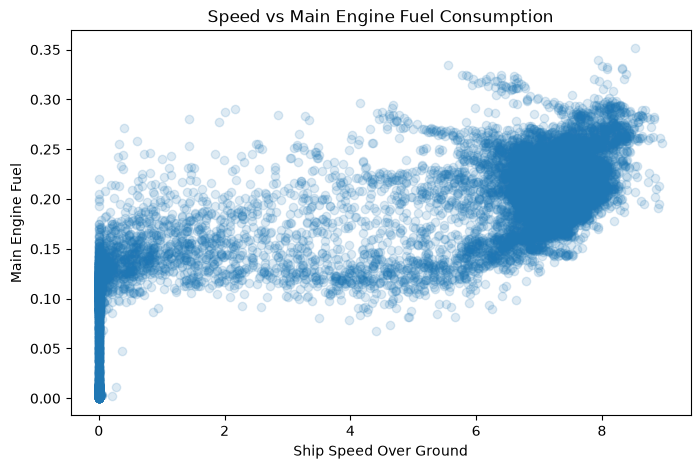

In [282]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.scatter(
    triton["Ship_SpeedOverGround"],
    triton["ME_Total_MomentaryFuel"],
    alpha=0.15
)

plt.xlabel("Ship Speed Over Ground")
plt.ylabel("Main Engine Fuel")
plt.title("Speed vs Main Engine Fuel Consumption")
plt.show()

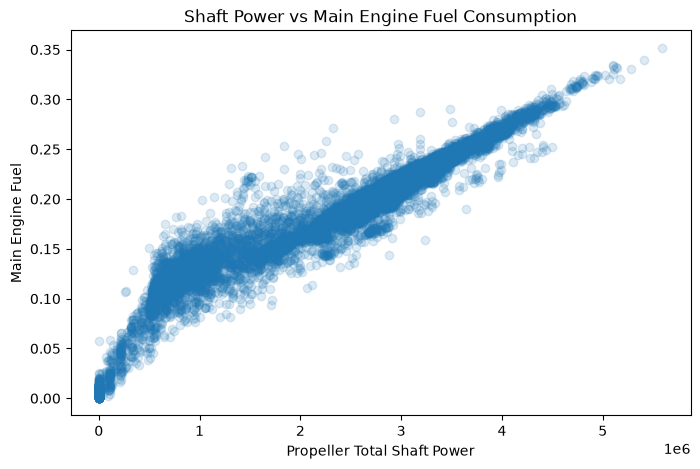

In [283]:
plt.figure(figsize=(8, 5))
plt.scatter(
    triton["Propeller_Total_ShaftPower"],
    triton["ME_Total_MomentaryFuel"],
    alpha=0.15
)

plt.xlabel("Propeller Total Shaft Power")
plt.ylabel("Main Engine Fuel")
plt.title("Shaft Power vs Main Engine Fuel Consumption")
plt.show()

In [284]:
# Keep only realistic operating points
analysis_df = triton[
    (triton["Ship_SpeedOverGround"] > 0) &
    (triton["Propeller_Total_ShaftPower"] > 0)
].copy()

print("Rows:", len(analysis_df))

Rows: 19831


In [285]:
analysis_df["speed_bin"] = pd.cut(
    analysis_df["Ship_SpeedOverGround"],
    bins=10
)

speed_fuel = analysis_df.groupby(
    "speed_bin",
    observed=True
)["ME_Total_MomentaryFuel"].agg(["count", "mean", "std"])

display(speed_fuel)

,count,mean,std
speed_bin,,,
"(0.00134, 0.905]",922,0.136301,0.028173
"(0.905, 1.801]",321,0.156337,0.029371
"(1.801, 2.696]",238,0.159530,0.036332
"(2.696, 3.591]",230,0.161981,0.043365
"(3.591, 4.486]",271,0.155704,0.047002
"(4.486, 5.381]",357,0.169925,0.053347
"(5.381, 6.276]",655,0.189584,0.050026
"(6.276, 7.171]",5269,0.207008,0.027885
"(7.171, 8.066]",11116,0.213046,0.020775


In [286]:
analysis_df["speed_bin"] = pd.cut(
    analysis_df["Ship_SpeedOverGround"],
    bins=10
)

speed_fuel = analysis_df.groupby(
    "speed_bin",
    observed=True
)["ME_Total_MomentaryFuel"].agg(["count", "mean", "std"])

display(speed_fuel)

,count,mean,std
speed_bin,,,
"(0.00134, 0.905]",922,0.136301,0.028173
"(0.905, 1.801]",321,0.156337,0.029371
"(1.801, 2.696]",238,0.159530,0.036332
"(2.696, 3.591]",230,0.161981,0.043365
"(3.591, 4.486]",271,0.155704,0.047002
"(4.486, 5.381]",357,0.169925,0.053347
"(5.381, 6.276]",655,0.189584,0.050026
"(6.276, 7.171]",5269,0.207008,0.027885
"(7.171, 8.066]",11116,0.213046,0.020775


In [287]:
# Check column metadata if available
print(df[[
    "Consumer_MainEnginePort_MomentaryFuel",
    "Consumer_MainEngineStarboard_MomentaryFuel",
    "ME_Total_MomentaryFuel"
]].head(10))

   Consumer_MainEnginePort_MomentaryFuel  \
0                                    NaN   
1                                    NaN   
2                                    NaN   
3                                    NaN   
4                                    NaN   
5                                    NaN   
6                                    NaN   
7                                    NaN   
8                                    NaN   
9                                    NaN   

   Consumer_MainEngineStarboard_MomentaryFuel  ME_Total_MomentaryFuel  
0                                         NaN                     NaN  
1                                         NaN                     NaN  
2                                         NaN                     NaN  
3                                         NaN                     NaN  
4                                         NaN                     NaN  
5                                         NaN                     NaN  
6          

In [288]:
# Only rows where main-engine fuel is available
valid_fuel = df[df["ME_Total_MomentaryFuel"].notna()].copy()

print("Valid fuel rows:", len(valid_fuel))
print("Vessels:")
print(valid_fuel["vessel_name"].value_counts())

Valid fuel rows: 25341
Vessels:
vessel_name
cps_triton    25341
Name: count, dtype: int64


In [289]:
valid_fuel[[
    "Consumer_MainEnginePort_MomentaryFuel",
    "Consumer_MainEngineStarboard_MomentaryFuel",
    "ME_Total_MomentaryFuel"
]].describe()

,Consumer_MainEnginePort_MomentaryFuel,Consumer_MainEngineStarboard_MomentaryFuel,ME_Total_MomentaryFuel
count,25341.000000,25341.000000,25341.000000
mean,0.090127,0.075257,0.165384
std,0.044119,0.038811,0.082403
min,0.000000,0.000000,0.000000
25%,0.075846,0.055901,0.131293
50%,0.109228,0.089982,0.199499
75%,0.117324,0.100994,0.217898
max,0.179608,0.172005,0.351613


In [290]:
fuel_cols = [
    "Consumer_MainEnginePort_MomentaryFuel",
    "Consumer_MainEngineStarboard_MomentaryFuel",
    "Consumer_Total_MomentaryFuel",
    "ME_Total_MomentaryFuel"
]

In [291]:
non_fuel_cols = [
    c for c in triton.columns
    if c not in fuel_cols
    and "Fuel" not in c
]

print("\n".join(non_fuel_cols))

Consumer_GeneratorEngine1_RotationSpeed
Consumer_GeneratorEngine1_ShaftPower
Consumer_GeneratorEngine2_RotationSpeed
Consumer_GeneratorEngine2_ShaftPower
Consumer_GeneratorEngine3_RotationSpeed
Consumer_GeneratorEngine3_ShaftPower
Consumer_GeneratorEngine4_RotationSpeed
Consumer_GeneratorEngine4_ShaftPower
Consumer_GeneratorEngine5_RotationSpeed
Consumer_GeneratorEngine5_ShaftPower
Consumer_Total_ShaftPower
Environment_SeaFloorDepth
Propeller_Port_RotationSpeed
Propeller_Port_ShaftPower
Propeller_Port_ShaftTorque
Propeller_Starboard_RotationSpeed
Propeller_Starboard_ShaftPower
Propeller_Starboard_ShaftTorque
Propeller_Total_ShaftPower
Ship_Bearing
Ship_Heading
Ship_SpeedOverGround
Ship_SpeedThroughWater
Weather_DiffuseRadiation
Weather_DirectNormalIrradiance
Weather_DirectRadiation
Weather_OceanCurrentDirection
Weather_OceanCurrentVelocity
Weather_Precipitation
Weather_RelativeHumidity2M
Weather_ShortwaveRadiation
Weather_SunshineDuration
Weather_SurfacePressure
Weather_SwellWaveDirect

In [292]:
ml_df = df[
    (df["vessel_name"] == "cps_triton") &
    (df["ME_Total_MomentaryFuel"].notna())
].copy()

print("Rows:", len(ml_df))
print("Columns:", ml_df.shape[1])

Rows: 25341
Columns: 94


In [293]:
fuel_columns = [
    c for c in ml_df.columns
    if "Fuel" in c or "fuel" in c
]

print(fuel_columns)

target = "ME_Total_MomentaryFuel"

['Consumer_Boiler1_FuelType', 'Consumer_Boiler1_MomentaryFuel', 'Consumer_Boiler2_FuelType', 'Consumer_Boiler2_MomentaryFuel', 'Consumer_GeneratorEngine1_FuelType', 'Consumer_GeneratorEngine1_MomentaryFuel', 'Consumer_GeneratorEngine2_FuelType', 'Consumer_GeneratorEngine2_MomentaryFuel', 'Consumer_GeneratorEngine3_FuelType', 'Consumer_GeneratorEngine3_MomentaryFuel', 'Consumer_GeneratorEngine4_FuelType', 'Consumer_GeneratorEngine4_MomentaryFuel', 'Consumer_GeneratorEngine5_FuelType', 'Consumer_GeneratorEngine5_MomentaryFuel', 'Consumer_Total_MomentaryFuel', 'Consumer_DeckSupply_FuelType', 'Consumer_DeckSupply_MomentaryFuel', 'Consumer_EngineRoom1_FuelType', 'Consumer_EngineRoom1_MomentaryFuel', 'Consumer_EngineRoom2_FuelType', 'Consumer_EngineRoom2_MomentaryFuel', 'Consumer_Incinerator_FuelType', 'Consumer_Incinerator_MomentaryFuel', 'Consumer_Boiler_FuelType', 'Consumer_Boiler_MomentaryFuel', 'Consumer_MainEnginePort_FuelType', 'Consumer_MainEnginePort_MomentaryFuel', 'Consumer_MainEn

In [294]:
features = [
    "Ship_SpeedOverGround",
    "Ship_SpeedThroughWater",
    "Consumer_MainEnginePort_ShaftPower",
    "Consumer_MainEngineStarboard_ShaftPower",
    "Propeller_Total_ShaftPower",
    "Ship_DraftAft",
    "Ship_DraftFore",
    "Propeller_Port_RotationSpeed",
    "Propeller_Starboard_RotationSpeed",
    "Weather_WindSpeed10M",
    "Weather_WindGusts10M",
    "Weather_WaveHeight",
    "Weather_WavePeriod",
    "Weather_SwellWaveHeight",
    "Weather_SwellWavePeriod",
    "Weather_OceanCurrentVelocity",
    "Weather_Temperature2M"
]

X = ml_df[features].copy()
y = ml_df[target].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (25341, 17)
y shape: (25341,)


In [295]:
missing = X.isna().sum().sort_values(ascending=False)

print(missing)

Weather_Temperature2M                      33
Weather_WavePeriod                         33
Weather_OceanCurrentVelocity               33
Weather_SwellWavePeriod                    33
Weather_SwellWaveHeight                    33
Weather_WindGusts10M                       33
Weather_WaveHeight                         33
Weather_WindSpeed10M                       33
Ship_SpeedOverGround                        0
Propeller_Starboard_RotationSpeed           0
Propeller_Port_RotationSpeed                0
Ship_DraftFore                              0
Ship_DraftAft                               0
Propeller_Total_ShaftPower                  0
Consumer_MainEngineStarboard_ShaftPower     0
Consumer_MainEnginePort_ShaftPower          0
Ship_SpeedThroughWater                      0
dtype: int64


In [296]:
print("Total missing values:", X.isna().sum().sum())

Total missing values: 264


In [297]:
X.head()

,Ship_SpeedOverGround,Ship_SpeedThroughWater,Consumer_MainEnginePort_ShaftPower,Consumer_MainEngineStarboard_ShaftPower,Propeller_Total_ShaftPower,Ship_DraftAft,Ship_DraftFore,Propeller_Port_RotationSpeed,Propeller_Starboard_RotationSpeed,Weather_WindSpeed10M,Weather_WindGusts10M,Weather_WaveHeight,Weather_WavePeriod,Weather_SwellWaveHeight,Weather_SwellWavePeriod,Weather_OceanCurrentVelocity,Weather_Temperature2M
148635,7.294816,0.514444,1273260.0,1276560.0,2549820.0,4.0496,6.3468,165.40,162.68,8.1,11.800000,1.400000,5.900000,0.580000,8.050,0.110000,3.8
148636,7.335971,0.514444,1270060.0,1246520.0,2516580.0,4.1118,6.3848,165.40,158.74,7.9,11.558333,1.368333,5.858333,0.571667,7.775,0.109167,3.8
148637,7.335971,0.514444,1260500.0,1267580.0,2528080.0,4.0644,6.3746,165.36,161.78,7.7,11.316667,1.336667,5.816667,0.563333,7.500,0.108333,3.8
148638,7.325683,0.514444,1268440.0,1240720.0,2509160.0,4.0786,6.4142,165.38,156.56,7.5,11.075000,1.305000,5.775000,0.555000,7.225,0.107500,3.8
148639,7.346260,0.514444,1270740.0,1282600.0,2553340.0,4.0542,6.3836,165.36,163.22,7.3,10.833333,1.273333,5.733333,0.546667,6.950,0.106667,3.8


In [298]:
outlier_check = X.describe().T[
    ["min", "25%", "50%", "75%", "max"]
]

display(outlier_check)

,min,25%,50%,75%,max
Ship_SpeedOverGround,0.000000,0.740799,7.109616e+00,7.438860e+00,8.961614e+00
Ship_SpeedThroughWater,0.514444,0.514444,5.144440e-01,5.144440e-01,5.144440e-01
Consumer_MainEnginePort_ShaftPower,0.000000,515180.000000,1.362380e+06,1.519280e+06,2.745080e+06
Consumer_MainEngineStarboard_ShaftPower,0.000000,479600.000000,1.335240e+06,1.501440e+06,2.846960e+06
Propeller_Total_ShaftPower,0.000000,990200.000000,2.700800e+06,3.016440e+06,5.592040e+06
Ship_DraftAft,3.493600,3.968800,4.028600e+00,4.093000e+00,4.790000e+00
Ship_DraftFore,4.618400,5.806800,6.335800e+00,6.952800e+00,7.000000e+00
Propeller_Port_RotationSpeed,-1.720000,164.520000,1.655800e+02,1.661400e+02,7.881200e+02
Propeller_Starboard_RotationSpeed,-1.920000,158.240000,1.618800e+02,1.637800e+02,3.537600e+02
Weather_WindSpeed10M,0.100000,3.333333,5.600000e+00,8.400000e+00,2.200000e+01


In [299]:
print(X.columns.tolist())

['Ship_SpeedOverGround', 'Ship_SpeedThroughWater', 'Consumer_MainEnginePort_ShaftPower', 'Consumer_MainEngineStarboard_ShaftPower', 'Propeller_Total_ShaftPower', 'Ship_DraftAft', 'Ship_DraftFore', 'Propeller_Port_RotationSpeed', 'Propeller_Starboard_RotationSpeed', 'Weather_WindSpeed10M', 'Weather_WindGusts10M', 'Weather_WaveHeight', 'Weather_WavePeriod', 'Weather_SwellWaveHeight', 'Weather_SwellWavePeriod', 'Weather_OceanCurrentVelocity', 'Weather_Temperature2M']


In [300]:
features = [
    "Ship_SpeedOverGround",
    "Consumer_MainEnginePort_ShaftPower",
    "Consumer_MainEngineStarboard_ShaftPower",
    "Propeller_Total_ShaftPower",
    "Ship_DraftAft",
    "Ship_DraftFore",
    "Propeller_Port_RotationSpeed",
    "Propeller_Starboard_RotationSpeed",
    "Weather_WindSpeed10M",
    "Weather_WindGusts10M",
    "Weather_WaveHeight",
    "Weather_WavePeriod",
    "Weather_SwellWaveHeight",
    "Weather_SwellWavePeriod",
    "Weather_OceanCurrentVelocity",
    "Weather_Temperature2M"
]

X = ml_df[features].copy()
y = ml_df["ME_Total_MomentaryFuel"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (25341, 16)
y shape: (25341,)


In [301]:
print(X.isna().sum().sort_values(ascending=False))

Weather_Temperature2M                      33
Weather_OceanCurrentVelocity               33
Weather_SwellWavePeriod                    33
Weather_SwellWaveHeight                    33
Weather_WavePeriod                         33
Weather_WaveHeight                         33
Weather_WindGusts10M                       33
Weather_WindSpeed10M                       33
Propeller_Starboard_RotationSpeed           0
Propeller_Port_RotationSpeed                0
Ship_DraftFore                              0
Ship_DraftAft                               0
Propeller_Total_ShaftPower                  0
Consumer_MainEngineStarboard_ShaftPower     0
Consumer_MainEnginePort_ShaftPower          0
Ship_SpeedOverGround                        0
dtype: int64


In [302]:
df_model = df.dropna(subset=["ME_Total_MomentaryFuel"]).copy()

print(df_model.shape)
print(df_model["vessel_name"].value_counts())

(25341, 94)
vessel_name
cps_triton    25341
Name: count, dtype: int64


In [303]:
X = df_model[features]
y = df_model[target]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (25341, 16)
y shape: (25341,)


In [304]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

X_train: (20272, 16)
X_test : (5069, 16)


In [305]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

X_train: (20272, 16)
X_test : (5069, 16)


In [306]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

X_train_processed = imputer.fit_transform(X_train)
X_test_processed = imputer.transform(X_test)

print("Missing in train:", pd.isna(X_train_processed).sum())
print("Missing in test :", pd.isna(X_test_processed).sum())

Missing in train: 0
Missing in test : 0


In [307]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

lr_model = LinearRegression()

lr_model.fit(X_train_processed, y_train)

y_pred_lr = lr_model.predict(X_test_processed)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Results")
print("-------------------------")
print("MAE :", mae_lr)
print("RMSE:", rmse_lr)
print("R²  :", r2_lr)

Linear Regression Results
-------------------------
MAE : 0.005855841498295701
RMSE: 0.009651350954520823
R²  : 0.9863938989096045


In [308]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_processed, y_train)

y_pred_rf = rf_model.predict(X_test_processed)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print("---------------------")
print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R²  :", r2_rf)

Random Forest Results
---------------------
MAE : 0.003262241552388764
RMSE: 0.006476571045863309
R²  : 0.9938730019131329


In [309]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train_processed, y_train)

y_pred_xgb = xgb_model.predict(X_test_processed)

mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print("XGBoost Results")
print("----------------")
print("MAE :", mae_xgb)
print("RMSE:", rmse_xgb)
print("R²  :", r2_xgb)

XGBoost Results
----------------
MAE : 0.0035275885409576362
RMSE: 0.00623980057621929
R²  : 0.9943127948230235


In [310]:
import pandas as pd
import matplotlib.pyplot as plt

importance_df = pd.DataFrame({
    "feature": features,
    "importance": xgb_model.feature_importances_
})

importance_df = importance_df.sort_values(
    "importance",
    ascending=False
)

print(importance_df)

                                    feature  importance
3                Propeller_Total_ShaftPower    0.513173
2   Consumer_MainEngineStarboard_ShaftPower    0.359823
1        Consumer_MainEnginePort_ShaftPower    0.111594
6              Propeller_Port_RotationSpeed    0.003789
7         Propeller_Starboard_RotationSpeed    0.003590
0                      Ship_SpeedOverGround    0.002585
5                            Ship_DraftFore    0.001263
15                    Weather_Temperature2M    0.000634
9                      Weather_WindGusts10M    0.000633
8                      Weather_WindSpeed10M    0.000578
11                       Weather_WavePeriod    0.000461
13                  Weather_SwellWavePeriod    0.000427
12                  Weather_SwellWaveHeight    0.000405
10                       Weather_WaveHeight    0.000375
14             Weather_OceanCurrentVelocity    0.000370
4                             Ship_DraftAft    0.000300


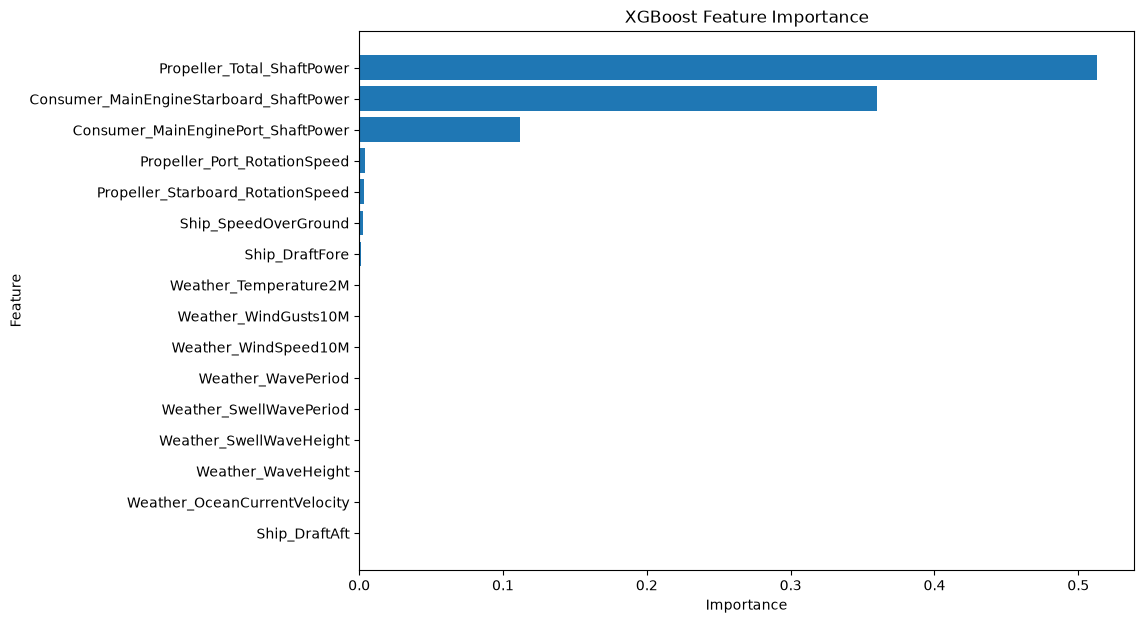

In [311]:
plt.figure(figsize=(10, 7))

plt.barh(
    importance_df["feature"],
    importance_df["importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("XGBoost Feature Importance")
plt.gca().invert_yaxis()

plt.show()

In [312]:
# Find possible time/date columns
time_cols = [
    col for col in df_model.columns
    if any(word in col.lower() for word in ["time", "date", "timestamp"])
]

print(time_cols)

[]


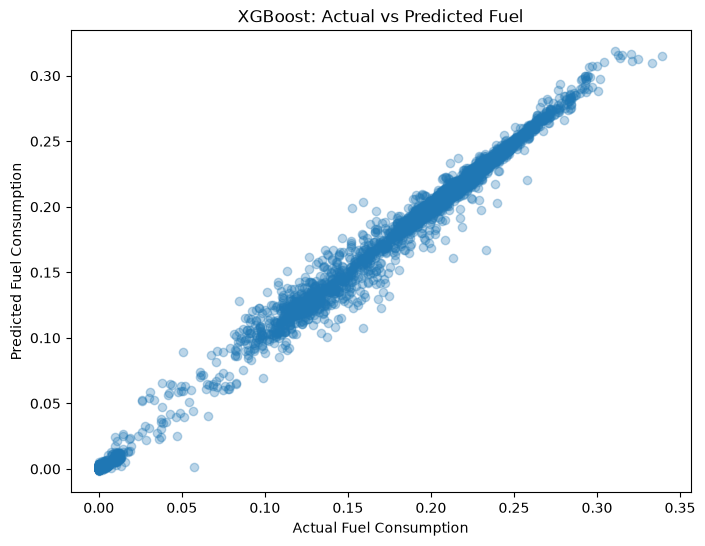

In [313]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred_xgb, alpha=0.3)

plt.xlabel("Actual Fuel Consumption")
plt.ylabel("Predicted Fuel Consumption")
plt.title("XGBoost: Actual vs Predicted Fuel")

plt.show()

In [314]:
residuals = y_test - y_pred_xgb

print("Mean residual:", residuals.mean())
print("Std residual :", residuals.std())
print("Min residual :", residuals.min())
print("Max residual :", residuals.max())

Mean residual: 1.1956895116965648e-05
Std residual : 0.006240404696423312
Min residual : -0.04707079650296106
Max residual : 0.06575584949387445


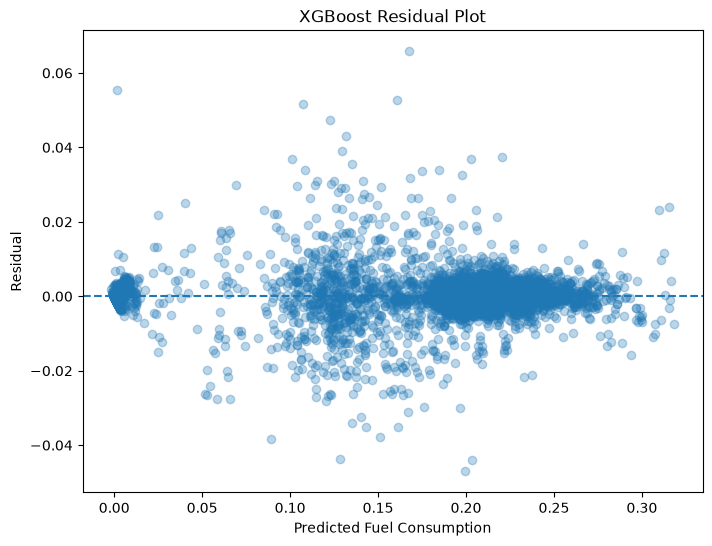

In [315]:
plt.figure(figsize=(8, 6))

plt.scatter(y_pred_xgb, residuals, alpha=0.3)
plt.axhline(0, linestyle="--")

plt.xlabel("Predicted Fuel Consumption")
plt.ylabel("Residual")
plt.title("XGBoost Residual Plot")

plt.show()

In [316]:
planning_features = [
    "Ship_SpeedOverGround",
    "Ship_DraftAft",
    "Ship_DraftFore",
    "Weather_WindSpeed10M",
    "Weather_WindGusts10M",
    "Weather_WaveHeight",
    "Weather_WavePeriod",
    "Weather_SwellWaveHeight",
    "Weather_SwellWavePeriod",
    "Weather_OceanCurrentVelocity",
    "Weather_Temperature2M"
]

X_plan = df_model[planning_features]
y_plan = df_model[target]

In [317]:
X_train_plan, X_test_plan, y_train_plan, y_test_plan = train_test_split(
    X_plan,
    y_plan,
    test_size=0.2,
    random_state=42
)

In [318]:
imputer_plan = SimpleImputer(strategy="median")

X_train_plan_processed = imputer_plan.fit_transform(X_train_plan)
X_test_plan_processed = imputer_plan.transform(X_test_plan)

In [319]:
xgb_plan = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_plan.fit(
    X_train_plan_processed,
    y_train_plan
)

y_pred_plan = xgb_plan.predict(X_test_plan_processed)

In [320]:
mae_plan = mean_absolute_error(y_test_plan, y_pred_plan)
rmse_plan = np.sqrt(mean_squared_error(y_test_plan, y_pred_plan))
r2_plan = r2_score(y_test_plan, y_pred_plan)

print("Planning XGBoost Results")
print("------------------------")
print("MAE :", mae_plan)
print("RMSE:", rmse_plan)
print("R²  :", r2_plan)

Planning XGBoost Results
------------------------
MAE : 0.015132389331100608
RMSE: 0.022043212795776954
R²  : 0.9290246957092764


In [321]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from xgboost import XGBRegressor
import joblib

planning_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", XGBRegressor(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    ))
])

planning_pipeline.fit(X_train_plan, y_train_plan)

print("Planning model trained successfully!")

Planning model trained successfully!


In [322]:
y_pred_pipeline = planning_pipeline.predict(X_test_plan)

print("MAE :", mean_absolute_error(y_test_plan, y_pred_pipeline))
print("RMSE:", np.sqrt(mean_squared_error(y_test_plan, y_pred_pipeline)))
print("R²  :", r2_score(y_test_plan, y_pred_pipeline))

MAE : 0.015132389331100608
RMSE: 0.022043212795776954
R²  : 0.9290246957092764


In [323]:
model_package = {
    "model": planning_pipeline,
    "features": planning_features,
    "target": target
}

joblib.dump(
    model_package,
    "green_fleet_fuel_model.joblib"
)

print("Model saved successfully!")

Model saved successfully!


In [324]:
import pandas as pd
def predict_fuel(input_data):
    
    """
    Predict fuel consumption for voyage conditions.
    """

    input_df = pd.DataFrame(
        [input_data],
        columns=planning_features
    )

    prediction = planning_pipeline.predict(input_df)

    return prediction[0]

In [325]:
sample_input = [
    8.0,      # Ship speed
    6.0,      # Draft aft
    6.0,      # Draft fore
    10.0,     # Wind speed
    15.0,     # Wind gust
    1.0,      # Wave height
    5.0,      # Wave period
    0.5,      # Swell height
    6.0,      # Swell period
    0.5,      # Ocean current
    20.0      # Temperature
]

fuel_prediction = predict_fuel(sample_input)

print("Predicted fuel:", fuel_prediction)

Predicted fuel: 0.21497414


In [326]:
import pandas as pd
import os

# --------------------------------------------------
# Create output folder
# --------------------------------------------------

output_dir = "data/processed"
os.makedirs(output_dir, exist_ok=True)


# --------------------------------------------------
# 1. VESSEL DATA
# --------------------------------------------------

vessels = pd.DataFrame([
    {
        "vessel_id": "V001",
        "vessel_type": "Container",
        "capacity_tonnes": 12000,
        "engine_power_kw": 22000,
        "max_speed_knots": 22,
        "min_speed_knots": 8,
        "fuel_compatible": "HFO,LNG,Methanol"
    },
    {
        "vessel_id": "V002",
        "vessel_type": "Tanker",
        "capacity_tonnes": 30000,
        "engine_power_kw": 18000,
        "max_speed_knots": 18,
        "min_speed_knots": 7,
        "fuel_compatible": "HFO,LNG"
    },
    {
        "vessel_id": "V003",
        "vessel_type": "Bulk_Carrier",
        "capacity_tonnes": 45000,
        "engine_power_kw": 25000,
        "max_speed_knots": 17,
        "min_speed_knots": 7,
        "fuel_compatible": "HFO,Methanol,Ammonia"
    },
    {
        "vessel_id": "V004",
        "vessel_type": "RoRo",
        "capacity_tonnes": 8000,
        "engine_power_kw": 15000,
        "max_speed_knots": 20,
        "min_speed_knots": 8,
        "fuel_compatible": "LNG,Methanol"
    },
    {
        "vessel_id": "V005",
        "vessel_type": "Ferry",
        "capacity_tonnes": 5000,
        "engine_power_kw": 12000,
        "max_speed_knots": 22,
        "min_speed_knots": 10,
        "fuel_compatible": "LNG,Hydrogen"
    }
])

vessels.to_csv(
    os.path.join(output_dir, "vessels.csv"),
    index=False
)


# --------------------------------------------------
# 2. ROUTE DATA
# --------------------------------------------------

routes = pd.DataFrame([
    {
        "route_id": "R001",
        "origin": "Mumbai",
        "destination": "Dubai",
        "distance_nmi": 1050,
        "speed_limit_knots": 20
    },
    {
        "route_id": "R002",
        "origin": "Chennai",
        "destination": "Singapore",
        "distance_nmi": 1580,
        "speed_limit_knots": 18
    },
    {
        "route_id": "R003",
        "origin": "Kochi",
        "destination": "Colombo",
        "distance_nmi": 325,
        "speed_limit_knots": 18
    },
    {
        "route_id": "R004",
        "origin": "Kolkata",
        "destination": "Port Klang",
        "distance_nmi": 1700,
        "speed_limit_knots": 18
    }
])

routes.to_csv(
    os.path.join(output_dir, "routes.csv"),
    index=False
)


# --------------------------------------------------
# 3. VOYAGE / CARGO DEMAND DATA
# --------------------------------------------------

voyages = pd.DataFrame([
    {
        "voyage_id": "VOY001",
        "route_id": "R001",
        "cargo_demand_tonnes": 8000,
        "deadline_hours": 60
    },
    {
        "voyage_id": "VOY002",
        "route_id": "R002",
        "cargo_demand_tonnes": 15000,
        "deadline_hours": 100
    },
    {
        "voyage_id": "VOY003",
        "route_id": "R003",
        "cargo_demand_tonnes": 3000,
        "deadline_hours": 24
    },
    {
        "voyage_id": "VOY004",
        "route_id": "R004",
        "cargo_demand_tonnes": 20000,
        "deadline_hours": 110
    }
])

voyages.to_csv(
    os.path.join(output_dir, "voyages.csv"),
    index=False
)


# --------------------------------------------------
# 4. FUEL DATA
# --------------------------------------------------

fuels = pd.DataFrame([
    {
        "fuel_type": "HFO",
        "energy_density_mj_kg": 40.5,
        "price_per_tonne": 550,
        "ttw_co2_kg_per_kg_fuel": 3.114,
        "wtw_ghg_kg_per_kg_fuel": 3.5
    },
    {
        "fuel_type": "LNG",
        "energy_density_mj_kg": 50.0,
        "price_per_tonne": 700,
        "ttw_co2_kg_per_kg_fuel": 2.75,
        "wtw_ghg_kg_per_kg_fuel": 3.2
    },
    {
        "fuel_type": "Methanol",
        "energy_density_mj_kg": 19.9,
        "price_per_tonne": 900,
        "ttw_co2_kg_per_kg_fuel": 1.375,
        "wtw_ghg_kg_per_kg_fuel": 1.8
    },
    {
        "fuel_type": "Hydrogen",
        "energy_density_mj_kg": 120.0,
        "price_per_tonne": 2500,
        "ttw_co2_kg_per_kg_fuel": 0.0,
        "wtw_ghg_kg_per_kg_fuel": 1.0
    },
    {
        "fuel_type": "Ammonia",
        "energy_density_mj_kg": 18.6,
        "price_per_tonne": 1400,
        "ttw_co2_kg_per_kg_fuel": 0.0,
        "wtw_ghg_kg_per_kg_fuel": 0.5
    }
])

fuels.to_csv(
    os.path.join(output_dir, "fuels.csv"),
    index=False
)


# --------------------------------------------------
# VERIFY
# --------------------------------------------------

print("Synthetic datasets created successfully!\n")

print("Vessels :", vessels.shape)
print("Routes  :", routes.shape)
print("Voyages :", voyages.shape)
print("Fuels   :", fuels.shape)

print("\nFiles created:")
print(" - data/processed/vessels.csv")
print(" - data/processed/routes.csv")
print(" - data/processed/voyages.csv")
print(" - data/processed/fuels.csv")

Synthetic datasets created successfully!

Vessels : (5, 7)
Routes  : (4, 5)
Voyages : (4, 4)
Fuels   : (5, 5)

Files created:
 - data/processed/vessels.csv
 - data/processed/routes.csv
 - data/processed/voyages.csv
 - data/processed/fuels.csv


In [327]:
print("===== VESSELS =====")
display(vessels)

print("\n===== ROUTES =====")
display(routes)

print("\n===== VOYAGES =====")
display(voyages)

print("\n===== FUELS =====")
display(fuels)

===== VESSELS =====


,vessel_id,vessel_type,capacity_tonnes,engine_power_kw,max_speed_knots,min_speed_knots,fuel_compatible
0,V001,Container,12000,22000,22,8,"HFO,LNG,Methanol"
1,V002,Tanker,30000,18000,18,7,"HFO,LNG"
2,V003,Bulk_Carrier,45000,25000,17,7,"HFO,Methanol,Ammonia"
3,V004,RoRo,8000,15000,20,8,"LNG,Methanol"
4,V005,Ferry,5000,12000,22,10,"LNG,Hydrogen"



===== ROUTES =====


,route_id,origin,destination,distance_nmi,speed_limit_knots
0,R001,Mumbai,Dubai,1050,20
1,R002,Chennai,Singapore,1580,18
2,R003,Kochi,Colombo,325,18
3,R004,Kolkata,Port Klang,1700,18



===== VOYAGES =====


,voyage_id,route_id,cargo_demand_tonnes,deadline_hours
0,VOY001,R001,8000,60
1,VOY002,R002,15000,100
2,VOY003,R003,3000,24
3,VOY004,R004,20000,110



===== FUELS =====


,fuel_type,energy_density_mj_kg,price_per_tonne,ttw_co2_kg_per_kg_fuel,wtw_ghg_kg_per_kg_fuel
0,HFO,40.5,550,3.114,3.5
1,LNG,50.0,700,2.750,3.2
2,Methanol,19.9,900,1.375,1.8
3,Hydrogen,120.0,2500,0.000,1.0
4,Ammonia,18.6,1400,0.000,0.5


In [328]:
print("Vessel columns:")
print(vessels.columns.tolist())

print("\nRoute columns:")
print(routes.columns.tolist())

print("\nVoyage columns:")
print(voyages.columns.tolist())

print("\nFuel columns:")
print(fuels.columns.tolist())

Vessel columns:
['vessel_id', 'vessel_type', 'capacity_tonnes', 'engine_power_kw', 'max_speed_knots', 'min_speed_knots', 'fuel_compatible']

Route columns:
['route_id', 'origin', 'destination', 'distance_nmi', 'speed_limit_knots']

Voyage columns:
['voyage_id', 'route_id', 'cargo_demand_tonnes', 'deadline_hours']

Fuel columns:
['fuel_type', 'energy_density_mj_kg', 'price_per_tonne', 'ttw_co2_kg_per_kg_fuel', 'wtw_ghg_kg_per_kg_fuel']


In [329]:
def calculate_voyage_time(distance_nmi, speed_knots):
    if speed_knots <= 0:
        raise ValueError("Speed must be greater than 0.")
    
    return distance_nmi / speed_knots


# Test
time = calculate_voyage_time(1050, 10)

print("Voyage time:", time, "hours")

Voyage time: 105.0 hours


In [330]:
def calculate_voyage_time(distance_nmi, speed_knots):
    if speed_knots <= 0:
        raise ValueError("Speed must be greater than 0.")
    
    return distance_nmi / speed_knots


def check_vessel_feasibility(vessel, voyage, route, speed):
    capacity_ok = (
        vessel["capacity_tonnes"] >= voyage["cargo_demand_tonnes"]
    )

    speed_ok = (
        speed >= vessel["min_speed_knots"]
        and speed <= vessel["max_speed_knots"]
        and speed <= route["speed_limit_knots"]
    )

    return capacity_ok and speed_ok


def check_deadline(route, voyage, speed):
    voyage_time = calculate_voyage_time(
        route["distance_nmi"],
        speed
    )

    return voyage_time <= voyage["deadline_hours"]

In [331]:
vessel = vessels[vessels["vessel_id"] == "V001"].iloc[0]
route = routes[routes["route_id"] == "R001"].iloc[0]
voyage = voyages[voyages["voyage_id"] == "VOY001"].iloc[0]

speed = 15

voyage_time = calculate_voyage_time(
    route["distance_nmi"],
    speed
)

feasible = check_vessel_feasibility(
    vessel,
    voyage,
    route,
    speed
)

deadline_ok = check_deadline(
    route,
    voyage,
    speed
)

print("Voyage time:", voyage_time, "hours")
print("Capacity + speed feasible:", feasible)
print("Deadline satisfied:", deadline_ok)

Voyage time: 70.0 hours
Capacity + speed feasible: True
Deadline satisfied: False


In [332]:
def check_fuel_compatibility(vessel, fuel_type):
    compatible_fuels = vessel["fuel_compatible"].split("/")
    return fuel_type in compatible_fuels

In [333]:
print(check_fuel_compatibility(vessel, "LNG"))
print(check_fuel_compatibility(vessel, "Ammonia"))

False
False


In [334]:
def check_feasibility(vessel, voyage, route, fuel_type, speed):

    # 1. Capacity
    capacity_ok = (
        vessel["capacity_tonnes"] >= voyage["cargo_demand_tonnes"]
    )

    # 2. Speed
    speed_ok = (
        vessel["min_speed_knots"] <= speed <= vessel["max_speed_knots"]
        and speed <= route["speed_limit_knots"]
    )

    # 3. Deadline
    voyage_time = route["distance_nmi"] / speed
    deadline_ok = voyage_time <= voyage["deadline_hours"]

    # 4. Fuel compatibility
    compatible_fuels = vessel["fuel_compatible"].split(",")
    fuel_ok = fuel_type in compatible_fuels

    # Return detailed result
    return {
        "feasible": capacity_ok and speed_ok and deadline_ok and fuel_ok,
        "capacity_ok": capacity_ok,
        "speed_ok": speed_ok,
        "deadline_ok": deadline_ok,
        "fuel_ok": fuel_ok,
        "voyage_time": voyage_time
    }

In [335]:
vessel = vessels[vessels["vessel_id"] == "V001"].iloc[0]
route = routes[routes["route_id"] == "R001"].iloc[0]
voyage = voyages[voyages["voyage_id"] == "VOY001"].iloc[0]

print(check_feasibility(
    vessel,
    voyage,
    route,
    "LNG",
    17.5
))

{'feasible': True, 'capacity_ok': np.True_, 'speed_ok': np.True_, 'deadline_ok': np.True_, 'fuel_ok': True, 'voyage_time': np.float64(60.0)}


In [336]:
result = check_feasibility(
    vessel,
    voyage,
    route,
    "LNG",
    17.5
)

print("Feasible:", result["feasible"])
print("Capacity:", result["capacity_ok"])
print("Speed:", result["speed_ok"])
print("Deadline:", result["deadline_ok"])
print("Fuel:", result["fuel_ok"])
print("Voyage time:", result["voyage_time"])

Feasible: True
Capacity: True
Speed: True
Deadline: True
Fuel: True
Voyage time: 60.0


In [337]:
print(repr(vessel["fuel_compatible"]))

'HFO,LNG,Methanol'


In [338]:
print(vessels[["vessel_id", "fuel_compatible"]])

  vessel_id       fuel_compatible
0      V001      HFO,LNG,Methanol
1      V002               HFO,LNG
2      V003  HFO,Methanol,Ammonia
3      V004          LNG,Methanol
4      V005          LNG,Hydrogen


In [339]:
print(df["ME_Total_MomentaryFuel"].describe())

count    25341.000000
mean         0.165384
std          0.082403
min          0.000000
25%          0.131293
50%          0.199499
75%          0.217898
max          0.351613
Name: ME_Total_MomentaryFuel, dtype: float64


In [340]:
print(df[[
    "Consumer_MainEnginePort_MomentaryFuel",
    "Consumer_MainEngineStarboard_MomentaryFuel",
    "ME_Total_MomentaryFuel"
]].head(10))

   Consumer_MainEnginePort_MomentaryFuel  \
0                                    NaN   
1                                    NaN   
2                                    NaN   
3                                    NaN   
4                                    NaN   
5                                    NaN   
6                                    NaN   
7                                    NaN   
8                                    NaN   
9                                    NaN   

   Consumer_MainEngineStarboard_MomentaryFuel  ME_Total_MomentaryFuel  
0                                         NaN                     NaN  
1                                         NaN                     NaN  
2                                         NaN                     NaN  
3                                         NaN                     NaN  
4                                         NaN                     NaN  
5                                         NaN                     NaN  
6          

In [341]:
def calculate_voyage_fuel(fuel_rate_kg_per_s, voyage_time_hours):
    """
    Convert momentary fuel rate (kg/s) into
    total voyage fuel consumption (tonnes).
    """
    
    fuel_kg = fuel_rate_kg_per_s * voyage_time_hours * 3600
    fuel_tonnes = fuel_kg / 1000
    
    return fuel_tonnes

In [342]:
fuel_rate = 0.21497414
voyage_time = 60

fuel_tonnes = calculate_voyage_fuel(
    fuel_rate,
    voyage_time
)

print("Fuel rate:", fuel_rate, "kg/s")
print("Voyage time:", voyage_time, "hours")
print("Total voyage fuel:", fuel_tonnes, "tonnes")

Fuel rate: 0.21497414 kg/s
Voyage time: 60 hours
Total voyage fuel: 46.43441424 tonnes


In [343]:
vessel = vessels[vessels["vessel_id"] == "V001"].iloc[0]

route = routes[routes["route_id"] == "R001"].iloc[0]

voyage = voyages[voyages["voyage_id"] == "VOY001"].iloc[0]

fuel = fuels[fuels["fuel_type"] == "LNG"].iloc[0]

result = evaluate_voyage(
    vessel=vessel,
    voyage=voyage,
    route=route,
    fuel=fuel,
    speed=17.5,
    fuel_rate_kg_per_s=0.21497414
)

print(result)

NameError: name 'evaluate_voyage' is not defined

In [ ]:
def calculate_voyage_fuel(fuel_rate_kg_per_s, voyage_time_hours):
    fuel_kg = fuel_rate_kg_per_s * voyage_time_hours * 3600
    fuel_tonnes = fuel_kg / 1000
    
    return fuel_tonnes

In [ ]:
def calculate_fuel_cost(fuel_tonnes, price_per_tonne):
    return fuel_tonnes * price_per_tonne

In [ ]:
def calculate_wtw_ghg(fuel_tonnes, wtw_factor):
    return fuel_tonnes * wtw_factor

In [ ]:
def check_feasibility(vessel, voyage, route, fuel_type, speed):

    capacity_ok = (
        vessel["capacity_tonnes"] >= voyage["cargo_demand_tonnes"]
    )

    speed_ok = (
        vessel["min_speed_knots"] <= speed <= vessel["max_speed_knots"]
        and speed <= route["speed_limit_knots"]
    )

    voyage_time = route["distance_nmi"] / speed

    deadline_ok = (
        voyage_time <= voyage["deadline_hours"]
    )

    compatible_fuels = str(vessel["fuel_compatible"]).split(".")
    fuel_ok = fuel_type in compatible_fuels

    return {
        "feasible": (
            capacity_ok
            and speed_ok
            and deadline_ok
            and fuel_ok
        ),
        "capacity_ok": capacity_ok,
        "speed_ok": speed_ok,
        "deadline_ok": deadline_ok,
        "fuel_ok": fuel_ok,
        "voyage_time": voyage_time
    }

In [ ]:
def evaluate_voyage(
    vessel,
    voyage,
    route,
    fuel,
    speed,
    fuel_rate_kg_per_s
):
    
    feasibility = check_feasibility(
        vessel,
        voyage,
        route,
        fuel["fuel_type"],
        speed
    )
    
    if not feasibility["feasible"]:
        return {
            "feasible": False,
            "reason": feasibility
        }

    voyage_time_hours = route["distance_nmi"] / speed

    fuel_tonnes = calculate_voyage_fuel(
        fuel_rate_kg_per_s,
        voyage_time_hours
    )

    fuel_cost = calculate_fuel_cost(
        fuel_tonnes,
        fuel["price_per_tonne"]
    )

    wtw_ghg = calculate_wtw_ghg(
        fuel_tonnes,
        fuel["wtw_ghg_kg_per_kg_fuel"]
    )

    return {
        "feasible": True,
        "vessel_id": vessel["vessel_id"],
        "voyage_id": voyage["voyage_id"],
        "route_id": route["route_id"],
        "fuel_type": fuel["fuel_type"],
        "speed_knots": speed,
        "voyage_time_hours": voyage_time_hours,
        "fuel_tonnes": fuel_tonnes,
        "fuel_cost": fuel_cost,
        "wtw_ghg_tonnes": wtw_ghg
    }
    

In [ ]:
vessel = vessels[vessels["vessel_id"] == "V001"].iloc[0]
route = routes[routes["route_id"] == "R001"].iloc[0]
voyage = voyages[voyages["voyage_id"] == "VOY001"].iloc[0]
fuel = fuels[fuels["fuel_type"] == "LNG"].iloc[0]

result = evaluate_voyage(
    vessel=vessel,
    voyage=voyage,
    route=route,
    fuel=fuel,
    speed=17.5,
    fuel_rate_kg_per_s=0.21497414
)

print(result)

{'feasible': False, 'reason': {'feasible': False, 'capacity_ok': np.True_, 'speed_ok': np.True_, 'deadline_ok': np.True_, 'fuel_ok': False, 'voyage_time': np.float64(60.0)}}


In [ ]:
print(vessel["fuel_compatible"])
print(fuel["fuel_type"])

HFO,LNG,Methanol
LNG


In [ ]:
print("RAW compatible:", repr(vessel["fuel_compatible"]))
print("RAW fuel type:", repr(fuel["fuel_type"]))

compatible_fuels = [
    f.strip()
    for f in str(vessel["fuel_compatible"]).split(",")
]

print("AFTER SPLIT:", compatible_fuels)
print("SEARCHING FOR:", repr(fuel_type))
print("MATCH:", fuel_type.strip() in compatible_fuels)

RAW compatible: 'HFO,LNG,Methanol'
RAW fuel type: 'LNG'
AFTER SPLIT: ['HFO', 'LNG', 'Methanol']


NameError: name 'fuel_type' is not defined

In [ ]:
def check_feasibility(vessel, voyage, route, fuel_type, speed):

    print("DEBUG fuel_type:", repr(fuel_type))

    capacity_ok = (
        vessel["capacity_tonnes"] >= voyage["cargo_demand_tonnes"]
    )

    speed_ok = (
        vessel["min_speed_knots"] <= speed <= vessel["max_speed_knots"]
        and speed <= route["speed_limit_knots"]
    )

    voyage_time = route["distance_nmi"] / speed

    deadline_ok = voyage_time <= voyage["deadline_hours"]

    compatible_fuels = [
        f.strip()
        for f in str(vessel["fuel_compatible"]).split(",")
    ]

    print("DEBUG compatible:", compatible_fuels)

    fuel_ok = fuel_type.strip() in compatible_fuels

    print("DEBUG fuel_ok:", fuel_ok)

    return {
        "feasible": capacity_ok and speed_ok and deadline_ok and fuel_ok,
        "capacity_ok": capacity_ok,
        "speed_ok": speed_ok,
        "deadline_ok": deadline_ok,
        "fuel_ok": fuel_ok,
        "voyage_time": voyage_time
    }

In [ ]:
check_feasibility(
    vessel,
    voyage,
    route,
    fuel["fuel_type"],
    17.5
)

DEBUG fuel_type: 'LNG'
DEBUG compatible: ['HFO', 'LNG', 'Methanol']
DEBUG fuel_ok: True


{'feasible': True,
 'capacity_ok': np.True_,
 'speed_ok': np.True_,
 'deadline_ok': np.True_,
 'fuel_ok': True,
 'voyage_time': np.float64(60.0)}

In [ ]:
result = evaluate_voyage(
    vessel=vessel,
    voyage=voyage,
    route=route,
    fuel=fuel,
    speed=17.5,
    fuel_rate_kg_per_s=0.21497414
)

print(result)

DEBUG fuel_type: 'LNG'
DEBUG compatible: ['HFO', 'LNG', 'Methanol']
DEBUG fuel_ok: True
{'feasible': True, 'vessel_id': 'V001', 'voyage_id': 'VOY001', 'route_id': 'R001', 'fuel_type': 'LNG', 'speed_knots': 17.5, 'voyage_time_hours': np.float64(60.0), 'fuel_tonnes': np.float64(46.43441424), 'fuel_cost': np.float64(32504.089968), 'wtw_ghg_tonnes': np.float64(148.59012556800002)}


In [ ]:
def predict_planning_fuel_rate(
    speed_knots,
    draft_aft,
    draft_fore,
    wind_speed,
    wind_gusts,
    wave_height,
    wave_period,
    swell_height,
    swell_period,
    current_velocity,
    temperature
):
    
    input_data = pd.DataFrame([{
        "Ship_SpeedOverGround": speed_knots * 0.514444,
        "Ship_DraftAft": draft_aft,
        "Ship_DraftFore": draft_fore,
        "Weather_WindSpeed10M": wind_speed,
        "Weather_WindGusts10M": wind_gusts,
        "Weather_WaveHeight": wave_height,
        "Weather_WavePeriod": wave_period,
        "Weather_SwellWaveHeight": swell_height,
        "Weather_SwellWavePeriod": swell_period,
        "Weather_OceanCurrentVelocity": current_velocity,
        "Weather_Temperature2M": temperature
    }], columns=planning_features)

    prediction = planning_pipeline.predict(input_data)

    return float(prediction[0])

In [ ]:
fuel_rate = predict_planning_fuel_rate(
    speed_knots=17.5,
    draft_aft=6.0,
    draft_fore=6.0,
    wind_speed=6.0,
    wind_gusts=8.0,
    wave_height=1.0,
    wave_period=5.0,
    swell_height=0.5,
    swell_period=6.0,
    current_velocity=0.5,
    temperature=20.0
)

print("Predicted fuel rate:", fuel_rate, "kg/s")

Predicted fuel rate: 0.2386925220489502 kg/s


In [ ]:
def evaluate_voyage_ml(
    vessel,
    voyage,
    route,
    fuel,
    speed,
    draft_aft=6.0,
    draft_fore=6.0,
    wind_speed=6.0,
    wind_gusts=8.0,
    wave_height=1.0,
    wave_period=5.0,
    swell_height=0.5,
    swell_period=6.0,
    current_velocity=0.5,
    temperature=20.0
):

    # 1. Check feasibility
    feasibility = check_feasibility(
        vessel,
        voyage,
        route,
        fuel["fuel_type"],
        speed
    )

    if not feasibility["feasible"]:
        return {
            "feasible": False,
            "reason": feasibility
        }

    # 2. Predict fuel rate using ML model
    fuel_rate = predict_planning_fuel_rate(
        speed_knots=speed,
        draft_aft=draft_aft,
        draft_fore=draft_fore,
        wind_speed=wind_speed,
        wind_gusts=wind_gusts,
        wave_height=wave_height,
        wave_period=wave_period,
        swell_height=swell_height,
        swell_period=swell_period,
        current_velocity=current_velocity,
        temperature=temperature
    )

    # 3. Calculate voyage time
    voyage_time_hours = route["distance_nmi"] / speed

    # 4. Calculate total fuel
    fuel_tonnes = calculate_voyage_fuel(
        fuel_rate,
        voyage_time_hours
    )

    # 5. Calculate cost
    fuel_cost = calculate_fuel_cost(
        fuel_tonnes,
        fuel["price_per_tonne"]
    )

    # 6. Calculate WTW GHG
    wtw_ghg = calculate_wtw_ghg(
        fuel_tonnes,
        fuel["wtw_ghg_kg_per_kg_fuel"]
    )

    return {
        "feasible": True,
        "vessel_id": vessel["vessel_id"],
        "voyage_id": voyage["voyage_id"],
        "route_id": route["route_id"],
        "fuel_type": fuel["fuel_type"],
        "speed_knots": speed,
        "fuel_rate_kg_per_s": fuel_rate,
        "voyage_time_hours": voyage_time_hours,
        "fuel_tonnes": fuel_tonnes,
        "fuel_cost": fuel_cost,
        "wtw_ghg_tonnes": wtw_ghg
    }

In [ ]:
result = evaluate_voyage_ml(
    vessel=vessel,
    voyage=voyage,
    route=route,
    fuel=fuel,
    speed=17.5
)

print(result)

DEBUG fuel_type: 'LNG'
DEBUG compatible: ['HFO', 'LNG', 'Methanol']
DEBUG fuel_ok: True
{'feasible': True, 'vessel_id': 'V001', 'voyage_id': 'VOY001', 'route_id': 'R001', 'fuel_type': 'LNG', 'speed_knots': 17.5, 'fuel_rate_kg_per_s': 0.2386925220489502, 'voyage_time_hours': np.float64(60.0), 'fuel_tonnes': np.float64(51.55758476257324), 'fuel_cost': np.float64(36090.30933380127), 'wtw_ghg_tonnes': np.float64(164.9842712402344)}


In [ ]:
speeds = [17.5, 18.0, 19.0, 20.0]

for speed in speeds:

    result = evaluate_voyage_ml(
        vessel=vessel,
        voyage=voyage,
        route=route,
        fuel=fuel,
        speed=speed
    )

    print(
        f"Speed: {speed} kn | "
        f"Time: {result['voyage_time_hours']:.2f} h | "
        f"Fuel rate: {result['fuel_rate_kg_per_s']:.4f} kg/s | "
        f"Fuel: {result['fuel_tonnes']:.2f} t | "
        f"Cost: {result['fuel_cost']:.2f} | "
        f"GHG: {result['wtw_ghg_tonnes']:.2f} t"
    )

DEBUG fuel_type: 'LNG'
DEBUG compatible: ['HFO', 'LNG', 'Methanol']
DEBUG fuel_ok: True
Speed: 17.5 kn | Time: 60.00 h | Fuel rate: 0.2387 kg/s | Fuel: 51.56 t | Cost: 36090.31 | GHG: 164.98 t
DEBUG fuel_type: 'LNG'
DEBUG compatible: ['HFO', 'LNG', 'Methanol']
DEBUG fuel_ok: True
Speed: 18.0 kn | Time: 58.33 h | Fuel rate: 0.2387 kg/s | Fuel: 50.13 t | Cost: 35087.80 | GHG: 160.40 t
DEBUG fuel_type: 'LNG'
DEBUG compatible: ['HFO', 'LNG', 'Methanol']
DEBUG fuel_ok: True
Speed: 19.0 kn | Time: 55.26 h | Fuel rate: 0.2387 kg/s | Fuel: 47.49 t | Cost: 33241.07 | GHG: 151.96 t
DEBUG fuel_type: 'LNG'
DEBUG compatible: ['HFO', 'LNG', 'Methanol']
DEBUG fuel_ok: True
Speed: 20.0 kn | Time: 52.50 h | Fuel rate: 0.2387 kg/s | Fuel: 45.11 t | Cost: 31579.02 | GHG: 144.36 t


In [ ]:
for speed in [5, 6, 7, 8, 9, 10, 11, 12]:

    fuel_rate = predict_planning_fuel_rate(
        speed_knots=speed,
        draft_aft=6.0,
        draft_fore=6.0,
        wind_speed=6.0,
        wind_gusts=8.0,
        wave_height=1.0,
        wave_period=5.0,
        swell_height=0.5,
        swell_period=6.0,
        current_velocity=0.5,
        temperature=20.0
    )

    print(f"{speed:4.1f} kn → {fuel_rate:.6f} kg/s")

 5.0 kn → 0.154923 kg/s
 6.0 kn → 0.155661 kg/s
 7.0 kn → 0.154820 kg/s
 8.0 kn → 0.152337 kg/s
 9.0 kn → 0.152059 kg/s
10.0 kn → 0.152299 kg/s
11.0 kn → 0.158561 kg/s
12.0 kn → 0.180877 kg/s


In [ ]:
print("Minimum speed:", X_train["Ship_SpeedOverGround"].min())
print("Maximum speed:", X_train["Ship_SpeedOverGround"].max())

Minimum speed: 0.0
Maximum speed: 8.96161448


In [ ]:
print("Speed range in knots:")

print(
    X_train["Ship_SpeedOverGround"].min() / 0.514444,
    "to",
    X_train["Ship_SpeedOverGround"].max() / 0.514444
)

Speed range in knots:
0.0 to 17.419999999999998


In [ ]:
test_speeds = [12, 13, 14, 15, 16, 17, 17.4]

for speed in test_speeds:

    fuel_rate = predict_planning_fuel_rate(
        speed_knots=speed,
        draft_aft=6.0,
        draft_fore=6.0,
        wind_speed=6.0,
        wind_gusts=8.0,
        wave_height=1.0,
        wave_period=5.0,
        swell_height=0.5,
        swell_period=6.0,
        current_velocity=0.5,
        temperature=20.0
    )

    print(f"{speed:4.1f} kn → {fuel_rate:.6f} kg/s")

12.0 kn → 0.180877 kg/s
13.0 kn → 0.198358 kg/s
14.0 kn → 0.202125 kg/s
15.0 kn → 0.208485 kg/s
16.0 kn → 0.233390 kg/s
17.0 kn → 0.238693 kg/s
17.4 kn → 0.238693 kg/s


In [ ]:
voyages.loc[
    voyages["voyage_id"] == "VOY001",
    "deadline_hours"
] = 65

In [ ]:
print(
    voyages[voyages["voyage_id"] == "VOY001"]
)

  voyage_id route_id  cargo_demand_tonnes  deadline_hours
0    VOY001     R001                 8000              65


In [ ]:
result = evaluate_voyage_ml(
    vessel=vessel,
    voyage=voyages[voyages["voyage_id"] == "VOY001"].iloc[0],
    route=route,
    fuel=fuel,
    speed=17
)

print(result)

DEBUG fuel_type: 'LNG'
DEBUG compatible: ['HFO', 'LNG', 'Methanol']
DEBUG fuel_ok: True
{'feasible': True, 'vessel_id': 'V001', 'voyage_id': 'VOY001', 'route_id': 'R001', 'fuel_type': 'LNG', 'speed_knots': 17, 'fuel_rate_kg_per_s': 0.2386925220489502, 'voyage_time_hours': np.float64(61.76470588235294), 'fuel_tonnes': np.float64(53.07398431441363), 'fuel_cost': np.float64(37151.78902008954), 'wtw_ghg_tonnes': np.float64(169.83674980612363)}


In [ ]:
test_speeds = [12, 13, 14, 15, 16, 17]

for speed in test_speeds:

    result = evaluate_voyage_ml(
        vessel=vessel,
        voyage=voyages[voyages["voyage_id"] == "VOY001"].iloc[0],
        route=route,
        fuel=fuel,
        speed=speed
    )

    if result["feasible"]:
        print(
            f"Speed: {speed:4.1f} kn | "
            f"Time: {result['voyage_time_hours']:.2f} h | "
            f"Fuel rate: {result['fuel_rate_kg_per_s']:.4f} kg/s | "
            f"Fuel: {result['fuel_tonnes']:.2f} t | "
            f"Cost: {result['fuel_cost']:.2f} | "
            f"GHG: {result['wtw_ghg_tonnes']:.2f} t"
        )
    else:
        print(
            f"Speed: {speed:4.1f} kn | NOT FEASIBLE"
        )

DEBUG fuel_type: 'LNG'
DEBUG compatible: ['HFO', 'LNG', 'Methanol']
DEBUG fuel_ok: True
Speed: 12.0 kn | NOT FEASIBLE
DEBUG fuel_type: 'LNG'
DEBUG compatible: ['HFO', 'LNG', 'Methanol']
DEBUG fuel_ok: True
Speed: 13.0 kn | NOT FEASIBLE
DEBUG fuel_type: 'LNG'
DEBUG compatible: ['HFO', 'LNG', 'Methanol']
DEBUG fuel_ok: True
Speed: 14.0 kn | NOT FEASIBLE
DEBUG fuel_type: 'LNG'
DEBUG compatible: ['HFO', 'LNG', 'Methanol']
DEBUG fuel_ok: True
Speed: 15.0 kn | NOT FEASIBLE
DEBUG fuel_type: 'LNG'
DEBUG compatible: ['HFO', 'LNG', 'Methanol']
DEBUG fuel_ok: True
Speed: 16.0 kn | NOT FEASIBLE
DEBUG fuel_type: 'LNG'
DEBUG compatible: ['HFO', 'LNG', 'Methanol']
DEBUG fuel_ok: True
Speed: 17.0 kn | Time: 61.76 h | Fuel rate: 0.2387 kg/s | Fuel: 53.07 t | Cost: 37151.79 | GHG: 169.84 t


In [ ]:
def optimize_voyage_grid(voyage_id, speed_step=0.5):

    voyage = voyages[
        voyages["voyage_id"] == voyage_id
    ].iloc[0]

    route = routes[
        routes["route_id"] == voyage["route_id"]
    ].iloc[0]

    results = []

    for _, vessel in vessels.iterrows():

        # Try every fuel compatible with this vessel
        compatible_fuels = [
            f.strip()
            for f in str(vessel["fuel_compatible"]).split(",")
        ]

        for fuel_type in compatible_fuels:

            fuel = fuels[
                fuels["fuel_type"] == fuel_type
            ].iloc[0]

            # Respect vessel and route speed limits
            max_speed = min(
                vessel["max_speed_knots"],
                route["speed_limit_knots"]
            )

            min_speed = vessel["min_speed_knots"]

            speed = min_speed

            while speed <= max_speed:

                result = evaluate_voyage_ml(
                    vessel=vessel,
                    voyage=voyage,
                    route=route,
                    fuel=fuel,
                    speed=speed
                )

                if result["feasible"]:
                    results.append(result)

                speed += speed_step

    return pd.DataFrame(results)

In [ ]:
results = optimize_voyage_grid("VOY001")

print(results)

DEBUG fuel_type: 'HFO'
DEBUG compatible: ['HFO', 'LNG', 'Methanol']
DEBUG fuel_ok: True
DEBUG fuel_type: 'HFO'
DEBUG compatible: ['HFO', 'LNG', 'Methanol']
DEBUG fuel_ok: True
DEBUG fuel_type: 'HFO'
DEBUG compatible: ['HFO', 'LNG', 'Methanol']
DEBUG fuel_ok: True
DEBUG fuel_type: 'HFO'
DEBUG compatible: ['HFO', 'LNG', 'Methanol']
DEBUG fuel_ok: True
DEBUG fuel_type: 'HFO'
DEBUG compatible: ['HFO', 'LNG', 'Methanol']
DEBUG fuel_ok: True
DEBUG fuel_type: 'HFO'
DEBUG compatible: ['HFO', 'LNG', 'Methanol']
DEBUG fuel_ok: True
DEBUG fuel_type: 'HFO'
DEBUG compatible: ['HFO', 'LNG', 'Methanol']
DEBUG fuel_ok: True
DEBUG fuel_type: 'HFO'
DEBUG compatible: ['HFO', 'LNG', 'Methanol']
DEBUG fuel_ok: True
DEBUG fuel_type: 'HFO'
DEBUG compatible: ['HFO', 'LNG', 'Methanol']
DEBUG fuel_ok: True
DEBUG fuel_type: 'HFO'
DEBUG compatible: ['HFO', 'LNG', 'Methanol']
DEBUG fuel_ok: True
DEBUG fuel_type: 'HFO'
DEBUG compatible: ['HFO', 'LNG', 'Methanol']
DEBUG fuel_ok: True
DEBUG fuel_type: 'HFO'
DEBUG com

In [ ]:
print("Number of feasible solutions:", len(results))

Number of feasible solutions: 54


In [ ]:
best_cost = results.loc[
    results["fuel_cost"].idxmin()
]

print(best_cost)

feasible                      True
vessel_id                     V001
voyage_id                   VOY001
route_id                      R001
fuel_type                      HFO
speed_knots                   20.0
fuel_rate_kg_per_s        0.238693
voyage_time_hours             52.5
fuel_tonnes              45.112887
fuel_cost             24812.087667
wtw_ghg_tonnes          157.895103
Name: 7, dtype: object


In [ ]:
best_ghg = results.loc[
    results["wtw_ghg_tonnes"].idxmin()
]

print(best_ghg)

feasible                     True
vessel_id                    V003
voyage_id                  VOY001
route_id                     R001
fuel_type                 Ammonia
speed_knots                  17.0
fuel_rate_kg_per_s       0.238693
voyage_time_hours       61.764706
fuel_tonnes             53.073984
fuel_cost             74303.57804
wtw_ghg_tonnes          26.536992
Name: 37, dtype: object


In [ ]:
results.sort_values(
    "fuel_cost"
).head(10)

,feasible,vessel_id,voyage_id,route_id,fuel_type,speed_knots,fuel_rate_kg_per_s,voyage_time_hours,fuel_tonnes,fuel_cost,wtw_ghg_tonnes
7,True,V001,VOY001,R001,HFO,20.0,0.238693,52.500000,45.112887,24812.087667,157.895103
6,True,V001,VOY001,R001,HFO,19.5,0.238693,53.846154,46.269627,25448.295043,161.943696
5,True,V001,VOY001,R001,HFO,19.0,0.238693,55.263158,47.487249,26117.987018,166.205372
4,True,V001,VOY001,R001,HFO,18.5,0.238693,56.756757,48.770688,26823.878559,170.697409
3,True,V001,VOY001,R001,HFO,18.0,0.238693,58.333333,50.125430,27568.986297,175.439004
27,True,V002,VOY001,R001,HFO,18.0,0.238693,58.333333,50.125430,27568.986297,175.439004
26,True,V002,VOY001,R001,HFO,17.5,0.238693,60.000000,51.557585,28356.671619,180.451547
2,True,V001,VOY001,R001,HFO,17.5,0.238693,60.000000,51.557585,28356.671619,180.451547
1,True,V001,VOY001,R001,HFO,17.0,0.238693,61.764706,53.073984,29190.691373,185.758945
25,True,V002,VOY001,R001,HFO,17.0,0.238693,61.764706,53.073984,29190.691373,185.758945


In [ ]:
print(
    results[
        [
            "vessel_id",
            "fuel_type",
            "speed_knots",
            "fuel_rate_kg_per_s",
            "fuel_tonnes",
            "fuel_cost",
            "wtw_ghg_tonnes"
        ]
    ].tail(10)
)

   vessel_id fuel_type  speed_knots  fuel_rate_kg_per_s  fuel_tonnes  \
44      V004       LNG         19.5            0.238693    46.269627   
45      V004       LNG         20.0            0.238693    45.112887   
46      V004  Methanol         16.5            0.238693    54.682287   
47      V004  Methanol         17.0            0.238693    53.073984   
48      V004  Methanol         17.5            0.238693    51.557585   
49      V004  Methanol         18.0            0.238693    50.125430   
50      V004  Methanol         18.5            0.238693    48.770688   
51      V004  Methanol         19.0            0.238693    47.487249   
52      V004  Methanol         19.5            0.238693    46.269627   
53      V004  Methanol         20.0            0.238693    45.112887   

       fuel_cost  wtw_ghg_tonnes  
44  32388.739146      148.062808  
45  31579.020667      144.361237  
46  49214.058182       98.428116  
47  47766.585883       95.533172  
48  46401.826286       92.803653

In [ ]:
print(results["vessel_id"].value_counts())
print(results["fuel_type"].value_counts())

vessel_id
V001    24
V004    16
V002     8
V003     6
Name: count, dtype: int64
fuel_type
LNG         20
Methanol    18
HFO         14
Ammonia      2
Name: count, dtype: int64


In [ ]:
triton_power = df.loc[
    df["Ship_Name"] == "CPS_Triton",
    "Propeller_Total_ShaftPower"
]

print(triton_power.describe())

KeyError: 'Ship_Name'

In [ ]:
print(df.columns.tolist())


['Consumer_Boiler1_FuelType', 'Consumer_Boiler1_MomentaryFuel', 'Consumer_Boiler2_FuelType', 'Consumer_Boiler2_MomentaryFuel', 'Consumer_GeneratorEngine1_FuelType', 'Consumer_GeneratorEngine1_MomentaryFuel', 'Consumer_GeneratorEngine1_RotationSpeed', 'Consumer_GeneratorEngine1_ShaftPower', 'Consumer_GeneratorEngine2_FuelType', 'Consumer_GeneratorEngine2_MomentaryFuel', 'Consumer_GeneratorEngine2_RotationSpeed', 'Consumer_GeneratorEngine2_ShaftPower', 'Consumer_GeneratorEngine3_FuelType', 'Consumer_GeneratorEngine3_MomentaryFuel', 'Consumer_GeneratorEngine3_RotationSpeed', 'Consumer_GeneratorEngine3_ShaftPower', 'Consumer_GeneratorEngine4_FuelType', 'Consumer_GeneratorEngine4_MomentaryFuel', 'Consumer_GeneratorEngine4_RotationSpeed', 'Consumer_GeneratorEngine4_ShaftPower', 'Consumer_GeneratorEngine5_FuelType', 'Consumer_GeneratorEngine5_MomentaryFuel', 'Consumer_GeneratorEngine5_RotationSpeed', 'Consumer_GeneratorEngine5_ShaftPower', 'Consumer_Total_MomentaryFuel', 'Consumer_Total_Shaft

In [ ]:
[c for c in df.columns if "ship" in c.lower()]

['Ship_Bearing',
 'Ship_Heading',
 'Ship_SpeedOverGround',
 'Ship_SpeedThroughWater',
 'Ship_DraftAft',
 'Ship_DraftFore',
 'Ship_AirTemperature',
 'Ship_AnemometerWindDirection',
 'Ship_AnemometerWindSpeed']

In [ ]:
print(df["vessel"].value_counts())

KeyError: 'vessel'

In [ ]:
[c for c in df.columns if "vessel" in c.lower() or "ship" in c.lower()]

['Ship_Bearing',
 'Ship_Heading',
 'Ship_SpeedOverGround',
 'Ship_SpeedThroughWater',
 'vessel_name',
 'Ship_DraftAft',
 'Ship_DraftFore',
 'Ship_AirTemperature',
 'Ship_AnemometerWindDirection',
 'Ship_AnemometerWindSpeed']

In [ ]:

triton_power = df.loc[
    df["vessel_name"] == "CPS Triton",
    "Propeller_Total_ShaftPower"
]

print(triton_power.describe())

count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: Propeller_Total_ShaftPower, dtype: float64


In [ ]:
print(df["vessel_name"].value_counts())

vessel_name
cps_poseidon    105422
oss_ceto         43213
cps_triton       25351
Name: count, dtype: int64


In [ ]:
print(
    vessels[
        ["vessel_id", "vessel_type", "engine_power_kw"]
    ]
)

  vessel_id   vessel_type  engine_power_kw
0      V001     Container            22000
1      V002        Tanker            18000
2      V003  Bulk_Carrier            25000
3      V004          RoRo            15000
4      V005         Ferry            12000


In [ ]:
triton_power = df.loc[
    df["vessel_name"] == "CPS Triton",
    "Propeller_Total_ShaftPower"
]

print(triton_power.describe())

count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: Propeller_Total_ShaftPower, dtype: float64


In [ ]:
print(df["vessel_name"].unique())

<ArrowStringArray>
['cps_poseidon', 'oss_ceto', 'cps_triton']
Length: 3, dtype: str


In [ ]:
for name in df["vessel_name"].unique():
    print(repr(name))

'cps_poseidon'
'oss_ceto'
'cps_triton'


In [ ]:
triton_power = df.loc[
    df["vessel_name"] == "cps_triton",
    "Propeller_Total_ShaftPower"
]

print(triton_power.describe())

count    2.535100e+04
mean     2.178573e+06
std      1.250068e+06
min      0.000000e+00
25%      9.867400e+05
50%      2.700320e+06
75%      3.016380e+06
max      5.592040e+06
Name: Propeller_Total_ShaftPower, dtype: float64


In [ ]:
print("Total Triton rows:", len(triton_power))
print("Non-null power:", triton_power.notna().sum())

Total Triton rows: 25351
Non-null power: 25351


In [ ]:
REFERENCE_ENGINE_POWER = 22000

VESSEL_POWER_FACTORS = {}

for _, row in vessels.iterrows():

    VESSEL_POWER_FACTORS[row["vessel_id"]] = (
        row["engine_power_kw"] / REFERENCE_ENGINE_POWER
    )

print(VESSEL_POWER_FACTORS)

{'V001': 1.0, 'V002': 0.8181818181818182, 'V003': 1.1363636363636365, 'V004': 0.6818181818181818, 'V005': 0.5454545454545454}


In [ ]:
def calibrate_fuel_rate(
    ml_fuel_rate,
    vessel_id,
    fuel_type
):
    
    vessel_factor = VESSEL_POWER_FACTORS[vessel_id]

    fuel_factors = {
        "HFO": 1.00,
        "LNG": 0.95,
        "Methanol": 1.05,
        "Hydrogen": 0.90,
        "Ammonia": 1.10
    }

    fuel_factor = fuel_factors.get(fuel_type, 1.0)

    calibrated_rate = (
        ml_fuel_rate
        * vessel_factor
        * fuel_factor
    )

    return calibrated_rate

In [ ]:
REFERENCE_ENERGY_DENSITY = 40.5

In [ ]:
fuel_energy_factors = {}

for _, row in fuels.iterrows():

    fuel_energy_factors[row["fuel_type"]] = (
        REFERENCE_ENERGY_DENSITY
        / row["energy_density_mj_kg"]
    )

print(fuel_energy_factors)

{'HFO': 1.0, 'LNG': 0.81, 'Methanol': 2.035175879396985, 'Hydrogen': 0.3375, 'Ammonia': 2.1774193548387095}


In [ ]:
REFERENCE_ENGINE_POWER = 22000

VESSEL_POWER_FACTORS = {}

for _, row in vessels.iterrows():

    VESSEL_POWER_FACTORS[row["vessel_id"]] = (
        row["engine_power_kw"] / REFERENCE_ENGINE_POWER
    )

print(VESSEL_POWER_FACTORS)

{'V001': 1.0, 'V002': 0.8181818181818182, 'V003': 1.1363636363636365, 'V004': 0.6818181818181818, 'V005': 0.5454545454545454}


In [ ]:
def calibrate_fuel_rate(
    ml_fuel_rate,
    vessel_id,
    fuel_type
):
    
    # Vessel scaling
    vessel_factor = VESSEL_POWER_FACTORS[vessel_id]

    # Fuel energy-density adjustment
    energy_factor = fuel_energy_factors[fuel_type]

    calibrated_rate = (
        ml_fuel_rate
        * vessel_factor
        * energy_factor
    )

    return calibrated_rate

In [ ]:
ml_rate = 0.2386925220489502

for vessel_id in ["V001", "V002", "V003", "V004"]:
    
    for fuel_type in ["HFO", "LNG", "Methanol"]:
        
        rate = calibrate_fuel_rate(
            ml_rate,
            vessel_id,
            fuel_type
        )
        
        print(
            vessel_id,
            fuel_type,
            "→",
            round(rate, 4),
            "kg/s"
        )

NameError: name 'fuel_energy_factors' is not defined

In [ ]:
# ============================================
# CALIBRATION FACTORS
# ============================================

# 1. Vessel power factors
REFERENCE_ENGINE_POWER = 22000

VESSEL_POWER_FACTORS = {}

for _, row in vessels.iterrows():
    VESSEL_POWER_FACTORS[row["vessel_id"]] = (
        row["engine_power_kw"] / REFERENCE_ENGINE_POWER
    )


# 2. Fuel energy-density factors
REFERENCE_ENERGY_DENSITY = 40.5

fuel_energy_factors = {}

for _, row in fuels.iterrows():
    fuel_energy_factors[row["fuel_type"]] = (
        REFERENCE_ENERGY_DENSITY
        / row["energy_density_mj_kg"]
    )


# 3. Calibration function
def calibrate_fuel_rate(
    ml_fuel_rate,
    vessel_id,
    fuel_type
):

    vessel_factor = VESSEL_POWER_FACTORS[vessel_id]

    energy_factor = fuel_energy_factors[fuel_type]

    calibrated_rate = (
        ml_fuel_rate
        * vessel_factor
        * energy_factor
    )

    return calibrated_rate


# ============================================
# DISPLAY FACTORS
# ============================================

print("Vessel Power Factors:")
print(VESSEL_POWER_FACTORS)

print("\nFuel Energy Factors:")
print(fuel_energy_factors)

Vessel Power Factors:
{'V001': 1.0, 'V002': 0.8181818181818182, 'V003': 1.1363636363636365, 'V004': 0.6818181818181818, 'V005': 0.5454545454545454}

Fuel Energy Factors:
{'HFO': 1.0, 'LNG': 0.81, 'Methanol': 2.035175879396985, 'Hydrogen': 0.3375, 'Ammonia': 2.1774193548387095}


In [ ]:
ml_rate = 0.2386925220489502

for vessel_id in ["V001", "V002", "V003", "V004"]:

    for fuel_type in ["HFO", "LNG", "Methanol"]:

        rate = calibrate_fuel_rate(
            ml_rate,
            vessel_id,
            fuel_type
        )

        print(
            vessel_id,
            fuel_type,
            "→",
            round(rate, 4),
            "kg/s"
        )

V001 HFO → 0.2387 kg/s
V001 LNG → 0.1933 kg/s
V001 Methanol → 0.4858 kg/s
V002 HFO → 0.1953 kg/s
V002 LNG → 0.1582 kg/s
V002 Methanol → 0.3975 kg/s
V003 HFO → 0.2712 kg/s
V003 LNG → 0.2197 kg/s
V003 Methanol → 0.552 kg/s
V004 HFO → 0.1627 kg/s
V004 LNG → 0.1318 kg/s
V004 Methanol → 0.3312 kg/s


In [ ]:
def evaluate_voyage_ml(
    vessel,
    voyage,
    route,
    fuel,
    speed,
    draft_aft=6.0,
    draft_fore=6.0,
    wind_speed=6.0,
    wind_gusts=8.0,
    wave_height=1.0,
    wave_period=5.0,
    swell_height=0.5,
    swell_period=6.0,
    current_velocity=0.5,
    temperature=20.0
):

    # -----------------------------------------
    # 1. Check feasibility
    # -----------------------------------------

    feasibility = check_feasibility(
        vessel,
        voyage,
        route,
        fuel["fuel_type"],
        speed
    )

    if not feasibility["feasible"]:
        return {
            "feasible": False,
            "reason": feasibility
        }


    # -----------------------------------------
    # 2. ML baseline fuel-rate prediction
    # -----------------------------------------

    ml_baseline_fuel_rate = predict_planning_fuel_rate(
        speed_knots=speed,
        draft_aft=draft_aft,
        draft_fore=draft_fore,
        wind_speed=wind_speed,
        wind_gusts=wind_gusts,
        wave_height=wave_height,
        wave_period=wave_period,
        swell_height=swell_height,
        swell_period=swell_period,
        current_velocity=current_velocity,
        temperature=temperature
    )


    # -----------------------------------------
    # 3. Scenario calibration
    # -----------------------------------------

    calibrated_fuel_rate = calibrate_fuel_rate(
        ml_fuel_rate=ml_baseline_fuel_rate,
        vessel_id=vessel["vessel_id"],
        fuel_type=fuel["fuel_type"]
    )


    # -----------------------------------------
    # 4. Voyage time
    # -----------------------------------------

    voyage_time_hours = (
        route["distance_nmi"] / speed
    )


    # -----------------------------------------
    # 5. Total fuel consumption
    # -----------------------------------------

    fuel_tonnes = calculate_voyage_fuel(
        calibrated_fuel_rate,
        voyage_time_hours
    )


    # -----------------------------------------
    # 6. Fuel cost
    # -----------------------------------------

    fuel_cost = calculate_fuel_cost(
        fuel_tonnes,
        fuel["price_per_tonne"]
    )


    # -----------------------------------------
    # 7. WTW GHG
    # -----------------------------------------

    wtw_ghg = calculate_wtw_ghg(
        fuel_tonnes,
        fuel["wtw_ghg_kg_per_kg_fuel"]
    )


    # -----------------------------------------
    # 8. Return complete result
    # -----------------------------------------

    return {
        "feasible": True,

        "vessel_id": vessel["vessel_id"],
        "voyage_id": voyage["voyage_id"],
        "route_id": route["route_id"],
        "fuel_type": fuel["fuel_type"],

        "speed_knots": speed,

        # ML prediction before calibration
        "ml_baseline_fuel_rate": ml_baseline_fuel_rate,

        # Final rate used by optimizer
        "calibrated_fuel_rate": calibrated_fuel_rate,

        "voyage_time_hours": voyage_time_hours,

        "fuel_tonnes": fuel_tonnes,

        "fuel_cost": fuel_cost,

        "wtw_ghg_tonnes": wtw_ghg
    }

In [ ]:
voyage = voyages[
    voyages["voyage_id"] == "VOY001"
].iloc[0]

route = routes[
    routes["route_id"] == voyage["route_id"]
].iloc[0]

vessel = vessels[
    vessels["vessel_id"] == "V001"
].iloc[0]

fuel = fuels[
    fuels["fuel_type"] == "LNG"
].iloc[0]

In [ ]:
result = evaluate_voyage_ml(
    vessel=vessel,
    voyage=voyage,
    route=route,
    fuel=fuel,
    speed=17
)

result

{'feasible': False,
 'reason': {'feasible': np.False_,
  'capacity_ok': np.True_,
  'speed_ok': np.True_,
  'deadline_ok': np.False_,
  'fuel_ok': True,
  'voyage_time': np.float64(61.76470588235294)}}

In [ ]:
voyages[voyages["voyage_id"] == "VOY001"]

,voyage_id,route_id,cargo_demand_tonnes,deadline_hours
0,VOY001,R001,8000,60


In [ ]:
voyages.loc[
    voyages["voyage_id"] == "VOY001",
    "deadline_hours"
] = 65

In [ ]:
voyage = voyages[
    voyages["voyage_id"] == "VOY001"
].iloc[0]

In [ ]:
result = evaluate_voyage_ml(
    vessel=vessel,
    voyage=voyage,
    route=route,
    fuel=fuel,
    speed=17
)

result

NameError: name 'predict_planning_fuel_rate' is not defined

In [344]:
def predict_planning_fuel_rate(
    speed_knots,
    draft_aft,
    draft_fore,
    wind_speed,
    wind_gusts,
    wave_height,
    wave_period,
    swell_height,
    swell_period,
    current_velocity,
    temperature
):

    input_data = pd.DataFrame([{
        "Ship_SpeedOverGround": speed_knots * 0.514444,
        "Ship_DraftAft": draft_aft,
        "Ship_DraftFore": draft_fore,
        "Weather_WindSpeed10M": wind_speed,
        "Weather_WindGusts10M": wind_gusts,
        "Weather_WaveHeight": wave_height,
        "Weather_WavePeriod": wave_period,
        "Weather_SwellWaveHeight": swell_height,
        "Weather_SwellWavePeriod": swell_period,
        "Weather_OceanCurrentVelocity": current_velocity,
        "Weather_Temperature2M": temperature
    }], columns=planning_features)

    prediction = planning_pipeline.predict(input_data)

    return float(prediction[0])

In [345]:
test_rate = predict_planning_fuel_rate(
    speed_knots=17,
    draft_aft=6.0,
    draft_fore=6.0,
    wind_speed=6.0,
    wind_gusts=8.0,
    wave_height=1.0,
    wave_period=5.0,
    swell_height=0.5,
    swell_period=6.0,
    current_velocity=0.5,
    temperature=20.0
)

print("ML baseline fuel rate:", test_rate, "kg/s")

ML baseline fuel rate: 0.2386925220489502 kg/s


In [346]:
result = evaluate_voyage_ml(
    vessel=vessel,
    voyage=voyage,
    route=route,
    fuel=fuel,
    speed=17
)

result

{'feasible': False,
 'reason': {'feasible': np.False_,
  'capacity_ok': np.True_,
  'speed_ok': np.True_,
  'deadline_ok': np.False_,
  'fuel_ok': True,
  'voyage_time': np.float64(61.76470588235294)}}

In [347]:
print(
    voyages.loc[
        voyages["voyage_id"] == "VOY001",
        ["voyage_id", "deadline_hours"]
    ]
)

  voyage_id  deadline_hours
0    VOY001              60


In [348]:
voyages.loc[
    voyages["voyage_id"] == "VOY001",
    "deadline_hours"
] = 65

In [349]:
print(
    voyages.loc[
        voyages["voyage_id"] == "VOY001",
        ["voyage_id", "deadline_hours"]
    ]
)

  voyage_id  deadline_hours
0    VOY001              65


In [350]:
voyage = voyages[
    voyages["voyage_id"] == "VOY001"
].iloc[0]

print("Deadline:", voyage["deadline_hours"])

Deadline: 65


In [351]:
check = check_feasibility(
    vessel=vessel,
    voyage=voyage,
    route=route,
    fuel_type="LNG",
    speed=17
)

check

{'feasible': True,
 'capacity_ok': np.True_,
 'speed_ok': np.True_,
 'deadline_ok': np.True_,
 'fuel_ok': True,
 'voyage_time': np.float64(61.76470588235294)}

In [352]:
result = evaluate_voyage_ml(
    vessel=vessel,
    voyage=voyage,
    route=route,
    fuel=fuel,
    speed=17
)

result

NameError: name 'calculate_fuel_cost' is not defined

In [353]:
# ============================================
# VOYAGE CALCULATION HELPERS
# ============================================

def calculate_voyage_time(distance_nmi, speed_knots):
    """
    Calculate voyage time in hours.
    """
    if speed_knots <= 0:
        raise ValueError("Speed must be greater than 0.")

    return distance_nmi / speed_knots


def calculate_voyage_fuel(fuel_rate_kg_per_s, voyage_time_hours):
    """
    Convert fuel consumption rate (kg/s)
    into total voyage fuel (tonnes).
    """

    fuel_kg = (
        fuel_rate_kg_per_s
        * voyage_time_hours
        * 3600
    )

    fuel_tonnes = fuel_kg / 1000

    return fuel_tonnes


def calculate_fuel_cost(
    fuel_tonnes,
    price_per_tonne
):
    """
    Calculate total fuel cost.
    """

    return fuel_tonnes * price_per_tonne


def calculate_wtw_ghg(
    fuel_tonnes,
    wtw_factor
):
    """
    Calculate Well-to-Wake GHG emissions.

    Output: tonnes CO2e
    """

    return fuel_tonnes * wtw_factor

In [354]:
fuel = calculate_voyage_fuel(
    fuel_rate_kg_per_s=0.1933,
    voyage_time_hours=61.7647
)

cost = calculate_fuel_cost(
    fuel_tonnes=fuel,
    price_per_tonne=700
)

ghg = calculate_wtw_ghg(
    fuel_tonnes=fuel,
    wtw_factor=3.2
)

print("Fuel:", fuel, "tonnes")
print("Cost:", cost)
print("WTW GHG:", ghg, "tonnes CO2e")

Fuel: 42.980819436 tonnes
Cost: 30086.5736052
WTW GHG: 137.5386221952 tonnes CO2e


In [356]:
fuel = fuels[
    fuels["fuel_type"] == "LNG"
].iloc[0]

print(fuel["fuel_type"])
print(fuel["price_per_tonne"])

LNG
700


In [357]:
result = evaluate_voyage_ml(
    vessel=vessel,
    voyage=voyage,
    route=route,
    fuel=fuel,
    speed=17
)

result

{'feasible': True,
 'vessel_id': 'V001',
 'voyage_id': 'VOY001',
 'route_id': 'R001',
 'fuel_type': 'LNG',
 'speed_knots': 17,
 'ml_baseline_fuel_rate': 0.2386925220489502,
 'calibrated_fuel_rate': 0.19334094285964967,
 'voyage_time_hours': np.float64(61.76470588235294),
 'fuel_tonnes': np.float64(42.98992729467504),
 'fuel_cost': np.float64(30092.94910627253),
 'wtw_ghg_tonnes': np.float64(137.56776734296014)}

In [362]:
def optimize_voyage_grid(voyage_id, speed_step=0.5):

    voyage = voyages[
        voyages["voyage_id"] == voyage_id
    ].iloc[0]

    route = routes[
        routes["route_id"] == voyage["route_id"]
    ].iloc[0]

    results = []

    # Maximum speed supported by our ML training data
    ML_MAX_SPEED_KNOTS = 17.0

    for _, vessel in vessels.iterrows():

        compatible_fuels = [
            f.strip()
            for f in str(vessel["fuel_compatible"]).split(",")
        ]

        for fuel_type in compatible_fuels:

            fuel = fuels[
                fuels["fuel_type"] == fuel_type
            ].iloc[0]

            max_speed = min(
                vessel["max_speed_knots"],
                route["speed_limit_knots"],
                ML_MAX_SPEED_KNOTS
            )

            min_speed = vessel["min_speed_knots"]

            speed = min_speed

            while speed <= max_speed:

                result = evaluate_voyage_ml(
                    vessel=vessel,
                    voyage=voyage,
                    route=route,
                    fuel=fuel,
                    speed=speed
                )

                if result["feasible"]:
                    results.append(result)

                speed += speed_step

    return pd.DataFrame(results)

In [366]:
grid_results = optimize_voyage_grid(
    voyage_id="VOY001",
    speed_step=0.5
)

print("Feasible solutions:", len(grid_results))

Feasible solutions: 20


In [367]:
grid_results[
    [
        "vessel_id",
        "fuel_type",
        "speed_knots",
        "ml_baseline_fuel_rate",
        "calibrated_fuel_rate",
        "voyage_time_hours",
        "fuel_tonnes",
        "fuel_cost",
        "wtw_ghg_tonnes"
    ]
].head(30)

,vessel_id,fuel_type,speed_knots,ml_baseline_fuel_rate,calibrated_fuel_rate,voyage_time_hours,fuel_tonnes,fuel_cost,wtw_ghg_tonnes
0,V001,HFO,16.5,0.238693,0.238693,63.636364,54.682287,30075.257778,191.388004
1,V001,HFO,17.0,0.238693,0.238693,61.764706,53.073984,29190.691373,185.758945
2,V001,LNG,16.5,0.238693,0.193341,63.636364,44.292652,31004.856655,141.736488
3,V001,LNG,17.0,0.238693,0.193341,61.764706,42.989927,30092.949106,137.567767
4,V001,Methanol,16.5,0.238693,0.485781,63.636364,111.288071,100159.264140,200.318528
5,V001,Methanol,17.0,0.238693,0.485781,61.764706,108.014893,97213.403430,194.426807
6,V002,HFO,16.5,0.238693,0.195294,63.636364,44.740053,24607.029091,156.590185
7,V002,HFO,17.0,0.238693,0.195294,61.764706,43.424169,23883.292941,151.984591
8,V002,LNG,16.5,0.238693,0.158188,63.636364,36.239443,25367.609990,115.966217
9,V002,LNG,17.0,0.238693,0.158188,61.764706,35.173577,24621.503814,112.555446


In [365]:
test_speeds = [
    10, 11, 12, 13, 14, 15, 16, 17
]

for speed in test_speeds:

    rate = predict_planning_fuel_rate(
        speed_knots=speed,
        draft_aft=6.0,
        draft_fore=6.0,
        wind_speed=6.0,
        wind_gusts=8.0,
        wave_height=1.0,
        wave_period=5.0,
        swell_height=0.5,
        swell_period=6.0,
        current_velocity=0.5,
        temperature=20.0
    )

    print(
        f"{speed:>5} knots → {rate:.6f} kg/s"
    )

   10 knots → 0.152299 kg/s
   11 knots → 0.158561 kg/s
   12 knots → 0.180877 kg/s
   13 knots → 0.198358 kg/s
   14 knots → 0.202125 kg/s
   15 knots → 0.208485 kg/s
   16 knots → 0.233390 kg/s
   17 knots → 0.238693 kg/s


In [368]:
# ============================================
# SPEED-FUEL REFERENCE CURVE
# ============================================

triton = df[
    (df["vessel_name"] == "cps_triton") &
    (df["ME_Total_MomentaryFuel"].notna())
].copy()

# Keep only realistic operational speeds
triton = triton[
    (triton["Ship_SpeedOverGround"] > 0) &
    (triton["Ship_SpeedOverGround"] <= 8.96)
].copy()

# Convert m/s → knots
triton["speed_knots"] = (
    triton["Ship_SpeedOverGround"] / 0.514444
)

# Create 0.5-knot bins
triton["speed_bin"] = (
    np.floor(triton["speed_knots"] * 2) / 2
)

speed_fuel_curve = (
    triton
    .groupby("speed_bin")["ME_Total_MomentaryFuel"]
    .agg(["mean", "median", "count"])
    .reset_index()
)

speed_fuel_curve.head(20)

,speed_bin,mean,median,count
0,0.0,0.100595,0.121136,619
1,0.5,0.142593,0.138676,187
2,1.0,0.149127,0.144416,160
3,1.5,0.156420,0.149855,122
4,2.0,0.156172,0.149901,88
5,2.5,0.156425,0.151848,110
6,3.0,0.156263,0.156018,83
7,3.5,0.156887,0.153806,79
8,4.0,0.157094,0.151933,78
9,4.5,0.167115,0.161033,50


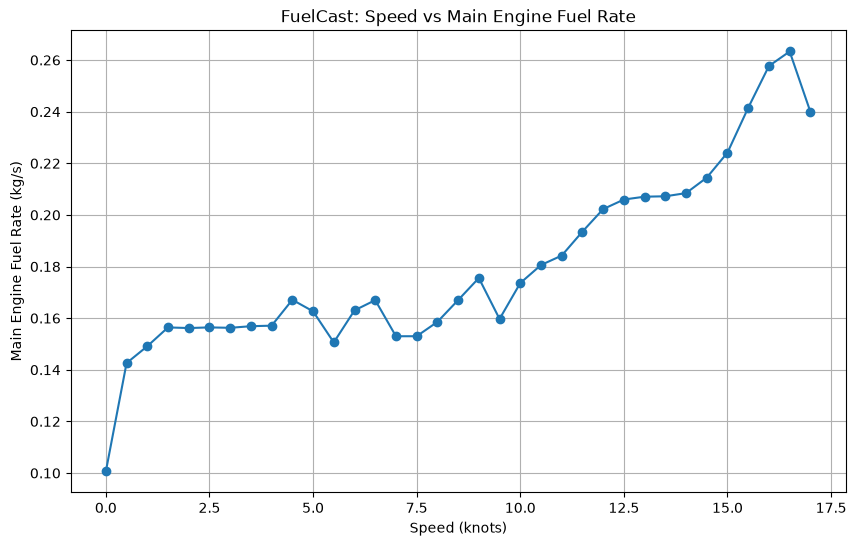

In [369]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(
    speed_fuel_curve["speed_bin"],
    speed_fuel_curve["mean"],
    marker="o"
)

plt.xlabel("Speed (knots)")
plt.ylabel("Main Engine Fuel Rate (kg/s)")
plt.title("FuelCast: Speed vs Main Engine Fuel Rate")

plt.grid(True)
plt.show()

In [370]:
speed_curve = speed_fuel_curve[
    (speed_fuel_curve["speed_bin"] >= 8) &
    (speed_fuel_curve["speed_bin"] <= 17)
].copy()

speed_curve

,speed_bin,mean,median,count
16,8.0,0.158550,0.138230,92
17,8.5,0.167000,0.146404,84
18,9.0,0.175552,0.169121,103
19,9.5,0.159689,0.141744,93
20,10.0,0.173600,0.158314,123
21,10.5,0.180596,0.187152,124
22,11.0,0.184249,0.184037,188
23,11.5,0.193537,0.191292,210
24,12.0,0.202258,0.206780,354
25,12.5,0.205963,0.208913,629


In [371]:
# ============================================
# SPEED-AWARE FUEL RATE
# ============================================

REFERENCE_SPEED = 14.0

# Use FuelCast observations with sufficient data
speed_reference_data = speed_fuel_curve[
    (speed_fuel_curve["speed_bin"] >= 10) &
    (speed_fuel_curve["speed_bin"] <= 16.5) &
    (speed_fuel_curve["count"] >= 50)
].copy()

# Smooth quadratic relationship
x = speed_reference_data["speed_bin"].values
y = speed_reference_data["mean"].values

speed_coefficients = np.polyfit(x, y, 2)
speed_reference_model = np.poly1d(speed_coefficients)

reference_fuel_rate = float(
    speed_reference_model(REFERENCE_SPEED)
)

print("Reference speed:", REFERENCE_SPEED, "knots")
print("Reference fuel rate:", reference_fuel_rate, "kg/s")

Reference speed: 14.0 knots
Reference fuel rate: 0.216582792446997 kg/s


In [372]:
def get_speed_correction(speed_knots):

    predicted_reference = float(
        speed_reference_model(speed_knots)
    )

    correction = (
        predicted_reference / reference_fuel_rate
    )

    return correction

In [373]:
for speed in [12, 13, 14, 15, 16, 17]:
    print(
        speed,
        "→ correction:",
        round(get_speed_correction(speed), 3)
    )

12 → correction: 0.894
13 → correction: 0.942
14 → correction: 1.0
15 → correction: 1.068
16 → correction: 1.145
17 → correction: 1.233


In [374]:
def predict_speed_aware_fuel_rate(
    speed_knots,
    draft_aft,
    draft_fore,
    wind_speed,
    wind_gusts,
    wave_height,
    wave_period,
    swell_height,
    swell_period,
    current_velocity,
    temperature
):

    # Original ML prediction
    ml_rate = predict_planning_fuel_rate(
        speed_knots=speed_knots,
        draft_aft=draft_aft,
        draft_fore=draft_fore,
        wind_speed=wind_speed,
        wind_gusts=wind_gusts,
        wave_height=wave_height,
        wave_period=wave_period,
        swell_height=swell_height,
        swell_period=swell_period,
        current_velocity=current_velocity,
        temperature=temperature
    )

    # Speed correction
    correction = get_speed_correction(speed_knots)

    speed_aware_rate = ml_rate * correction

    return float(speed_aware_rate)

In [375]:
for speed in [13, 14, 15, 16, 17]:

    rate = predict_speed_aware_fuel_rate(
        speed_knots=speed,
        draft_aft=6.0,
        draft_fore=6.0,
        wind_speed=6.0,
        wind_gusts=8.0,
        wave_height=1.0,
        wave_period=5.0,
        swell_height=0.5,
        swell_period=6.0,
        current_velocity=0.5,
        temperature=20.0
    )

    print(
        speed,
        "knots →",
        round(rate, 4),
        "kg/s"
    )

13 knots → 0.1869 kg/s
14 knots → 0.2021 kg/s
15 knots → 0.2226 kg/s
16 knots → 0.2673 kg/s
17 knots → 0.2942 kg/s


In [376]:
grid_results = optimize_voyage_grid(
    voyage_id="VOY001",
    speed_step=0.5
)

print("Feasible solutions:", len(grid_results))

Feasible solutions: 20


In [377]:
grid_results[
    [
        "vessel_id",
        "fuel_type",
        "speed_knots",
        "ml_baseline_fuel_rate",
        "calibrated_fuel_rate",
        "voyage_time_hours",
        "fuel_tonnes",
        "fuel_cost",
        "wtw_ghg_tonnes"
    ]
].head(20)

,vessel_id,fuel_type,speed_knots,ml_baseline_fuel_rate,calibrated_fuel_rate,voyage_time_hours,fuel_tonnes,fuel_cost,wtw_ghg_tonnes
0,V001,HFO,16.5,0.238693,0.238693,63.636364,54.682287,30075.257778,191.388004
1,V001,HFO,17.0,0.238693,0.238693,61.764706,53.073984,29190.691373,185.758945
2,V001,LNG,16.5,0.238693,0.193341,63.636364,44.292652,31004.856655,141.736488
3,V001,LNG,17.0,0.238693,0.193341,61.764706,42.989927,30092.949106,137.567767
4,V001,Methanol,16.5,0.238693,0.485781,63.636364,111.288071,100159.264140,200.318528
5,V001,Methanol,17.0,0.238693,0.485781,61.764706,108.014893,97213.403430,194.426807
6,V002,HFO,16.5,0.238693,0.195294,63.636364,44.740053,24607.029091,156.590185
7,V002,HFO,17.0,0.238693,0.195294,61.764706,43.424169,23883.292941,151.984591
8,V002,LNG,16.5,0.238693,0.158188,63.636364,36.239443,25367.609990,115.966217
9,V002,LNG,17.0,0.238693,0.158188,61.764706,35.173577,24621.503814,112.555446


In [378]:
for speed in [13, 14, 15, 16, 16.5, 17]:

    rate = predict_speed_aware_fuel_rate(
        speed_knots=speed,
        draft_aft=6.0,
        draft_fore=6.0,
        wind_speed=6.0,
        wind_gusts=8.0,
        wave_height=1.0,
        wave_period=5.0,
        swell_height=0.5,
        swell_period=6.0,
        current_velocity=0.5,
        temperature=20.0
    )

    print(f"{speed} kn → {rate:.6f} kg/s")

13 kn → 0.186866 kg/s
14 kn → 0.202125 kg/s
15 kn → 0.222608 kg/s
16 kn → 0.267299 kg/s
16.5 kn → 0.283504 kg/s
17 kn → 0.294221 kg/s


In [379]:
def evaluate_voyage_ml(
    vessel,
    voyage,
    route,
    fuel,
    speed,
    draft_aft=6.0,
    draft_fore=6.0,
    wind_speed=6.0,
    wind_gusts=8.0,
    wave_height=1.0,
    wave_period=5.0,
    swell_height=0.5,
    swell_period=6.0,
    current_velocity=0.5,
    temperature=20.0
):

    # 1. Feasibility
    feasibility = check_feasibility(
        vessel,
        voyage,
        route,
        fuel["fuel_type"],
        speed
    )

    if not feasibility["feasible"]:
        return {
            "feasible": False,
            "reason": feasibility
        }

    # 2. Speed-aware ML prediction
    ml_baseline_fuel_rate = predict_speed_aware_fuel_rate(
        speed_knots=speed,
        draft_aft=draft_aft,
        draft_fore=draft_fore,
        wind_speed=wind_speed,
        wind_gusts=wind_gusts,
        wave_height=wave_height,
        wave_period=wave_period,
        swell_height=swell_height,
        swell_period=swell_period,
        current_velocity=current_velocity,
        temperature=temperature
    )

    # 3. Vessel + fuel calibration
    calibrated_fuel_rate = calibrate_fuel_rate(
        ml_fuel_rate=ml_baseline_fuel_rate,
        vessel_id=vessel["vessel_id"],
        fuel_type=fuel["fuel_type"]
    )

    # 4. Voyage time
    voyage_time_hours = route["distance_nmi"] / speed

    # 5. Fuel
    fuel_tonnes = calculate_voyage_fuel(
        calibrated_fuel_rate,
        voyage_time_hours
    )

    # 6. Cost
    fuel_cost = calculate_fuel_cost(
        fuel_tonnes,
        fuel["price_per_tonne"]
    )

    # 7. WTW GHG
    wtw_ghg = calculate_wtw_ghg(
        fuel_tonnes,
        fuel["wtw_ghg_kg_per_kg_fuel"]
    )

    return {
        "feasible": True,
        "vessel_id": vessel["vessel_id"],
        "voyage_id": voyage["voyage_id"],
        "route_id": route["route_id"],
        "fuel_type": fuel["fuel_type"],
        "speed_knots": speed,
        "ml_baseline_fuel_rate": ml_baseline_fuel_rate,
        "calibrated_fuel_rate": calibrated_fuel_rate,
        "voyage_time_hours": voyage_time_hours,
        "fuel_tonnes": fuel_tonnes,
        "fuel_cost": fuel_cost,
        "wtw_ghg_tonnes": wtw_ghg
    }

In [380]:
grid_results = optimize_voyage_grid(
    voyage_id="VOY001",
    speed_step=0.5
)

In [381]:
grid_results[
    [
        "vessel_id",
        "fuel_type",
        "speed_knots",
        "ml_baseline_fuel_rate",
        "calibrated_fuel_rate",
        "fuel_tonnes",
        "fuel_cost",
        "wtw_ghg_tonnes"
    ]
].head(20)

,vessel_id,fuel_type,speed_knots,ml_baseline_fuel_rate,calibrated_fuel_rate,fuel_tonnes,fuel_cost,wtw_ghg_tonnes
0,V001,HFO,16.5,0.283504,0.283504,64.948085,35721.446565,227.318296
1,V001,HFO,17.0,0.294221,0.294221,65.420904,35981.496957,228.973162
2,V001,LNG,16.5,0.283504,0.229638,52.607949,36825.564005,168.345435
3,V001,LNG,17.0,0.294221,0.238319,52.990932,37093.652318,169.570982
4,V001,Methanol,16.5,0.283504,0.576980,132.180775,118962.697789,237.925396
5,V001,Methanol,17.0,0.294221,0.598791,133.143045,119828.740438,239.657481
6,V002,HFO,16.5,0.283504,0.231957,53.139342,29226.638099,185.987697
7,V002,HFO,17.0,0.294221,0.240726,53.526194,29439.406601,187.341678
8,V002,LNG,16.5,0.283504,0.187886,43.042867,30130.006913,137.737174
9,V002,LNG,17.0,0.294221,0.194988,43.356217,30349.351896,138.739894
